# Classical ML Baselines

RF, XGBoost, and LightGBM run as an ablation against each other, plus the naive/trivial per-user-median baseline predictor (a floor showing how much of any model's accuracy is genuine learning versus just reflecting a user's recent typical behavior), all under the same fixed Optuna tuning budget across model families.

**Scope for this pass:** F-DATA's `duration` (execution time) target only. EXPERIMENT_TRACKER.md's notebook 05 row lists only RF/XGBoost/LightGBM without naming a dataset (unlike notebook 03's row, which explicitly named both F-DATA and PM100), so this pass treats PM100 and F-DATA's other two targets (memory, power) as deferred to a follow-up pass rather than assumed in scope; see Summary below.

See the conceptualization plan and EXPERIMENT_TRACKER.md for full context.

In [1]:
import sys
sys.path.append("..")

from src import baselines, config, features, metrics, models, plotting, roofline, splits

## Config

In [2]:
import glob
import time

import numpy as np
import optuna
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

FDATA_DIR = "../data/raw/fdata"
N_CONSECUTIVE_MONTHS = 38     # full F-DATA -- every month
SAMPLE_SIZE = 1_000_000       # rows for the Optuna TUNING sample only (stratified within the
                             # train split); the final fit uses the full train split below
RF_FINAL_FIT_CAP = 5_000_000  # RandomForest final fit is capped here (sklearn RF has no GPU
                             # path and gains little past a few million rows); XGBoost and
                             # LightGBM fit on the entire train split
SHAP_SAMPLE = 200_000        # SHAP on a sample of the full test set (exact SHAP over ~7M rows
                             # is too slow)
PLOT_SAMPLE = 200_000        # rows sampled from the full test split for the scatter / residual /
                             # error-by-size / boxplot figures (Steps 13b, 13b-ii/iii, 13f)
TARGET_COL = "duration"   # F-DATA execution time
N_TRIALS = models.TuningBudget().n_trials  # fixed tuning budget, same for every model family
SEED = 0
N_BUCKETS = 5              # job-size stratification buckets (cnumr-based)
EMBEDDING_VARIANCE_THRESHOLD = 0.90
TUNE_TRAIN_FRAC = 0.8      # chronological carve-out WITHIN train_sample: first 80% tunes, last 20% validates

print(f"N_CONSECUTIVE_MONTHS={N_CONSECUTIVE_MONTHS}  tuning SAMPLE_SIZE={SAMPLE_SIZE:,}  "
      f"RF_FINAL_FIT_CAP={RF_FINAL_FIT_CAP:,}  PLOT_SAMPLE={PLOT_SAMPLE:,}  TARGET_COL={TARGET_COL}")

N_CONSECUTIVE_MONTHS=38  tuning SAMPLE_SIZE=1,000,000  RF_FINAL_FIT_CAP=5,000,000  PLOT_SAMPLE=200,000  TARGET_COL=duration


/home/bizon/Documents/tobi/hpc-dl-enhanced/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Load all 38 F-DATA months + exclude non-completed jobs

The full F-DATA dataset (all 38 contiguous months, ~23.3M completed jobs), loaded without the embedding column via `features.load_fdata_no_embedding`. Non-completed jobs (failed/cancelled/timed-out) are excluded since their duration/power are artifacts of not finishing normally, not real workload behavior.

In [3]:
fdata_files = sorted(glob.glob(f"{FDATA_DIR}/*.parquet"))[:N_CONSECUTIVE_MONTHS]
print(f"Loading {len(fdata_files)} months: {[f.split('/')[-1] for f in fdata_files]}")

fdata = features.load_fdata_no_embedding(fdata_files)
fdata = features.filter_completed_jobs(fdata, "fdata")
print(f"rows after filtering: {len(fdata):,}")

Loading 38 months: ['21_03.parquet', '21_04.parquet', '21_05.parquet', '21_06.parquet', '21_07.parquet', '21_08.parquet', '21_09.parquet', '21_10.parquet', '21_11.parquet', '21_12.parquet', '22_01.parquet', '22_02.parquet', '22_03.parquet', '22_04.parquet', '22_05.parquet', '22_06.parquet', '22_07.parquet', '22_08.parquet', '22_09.parquet', '22_10.parquet', '22_11.parquet', '22_12.parquet', '23_01.parquet', '23_02.parquet', '23_03.parquet', '23_04.parquet', '23_05.parquet', '23_06.parquet', '23_07.parquet', '23_08.parquet', '23_09.parquet', '23_10.parquet', '23_11.parquet', '23_12.parquet', '24_01.parquet', '24_02.parquet', '24_03.parquet', '24_04.parquet']


[fdata] excluded 9.9% of jobs as non-completed (2558519 / 25866900)
rows after filtering: 23,308,381


## Step 2: `mszl` sentinel fix

`mszl` (memory size limit requested, Tier A) uses an unsigned-int sentinel (`2**64 - 1`) for "no limit requested" rather than a null. Found while scratch-timing this notebook's `SAMPLE_SIZE` decision, where it broke XGBoost/LightGBM's histogram binning (see EXPERIMENT_TRACKER.md Data Gotchas). Fixed for real here via `src/features.py`, not the scratch script's throwaway exclusion.

In [4]:
n_sentinel_before = int((fdata["mszl"] >= 1e15).sum())
print(f"mszl sentinel rows before fix: {n_sentinel_before:,} / {len(fdata):,} "
      f"({n_sentinel_before / len(fdata):.1%})")

fdata = features.handle_mszl_sentinel(fdata)
features.assert_mszl_sanitized(fdata)

print(f"mszl range after fix: [{fdata['mszl'].min():.3g}, {fdata['mszl'].max():.3g}]")
print(f"mszl_unlimited True: {fdata['mszl_unlimited'].sum():,} ({fdata['mszl_unlimited'].mean():.1%})")

mszl sentinel rows before fix: 20,384,093 / 23,308,381 (87.5%)


mszl range after fix: [0, 3.06e+10]
mszl_unlimited True: 20,384,093 (87.5%)


## Step 3: Historical rolling-stat feature (Tier A)

Computed on the full chronologically-ordered dataset, **before** the split/sample below. The function itself only ever looks backward (`shift(1)` before the rolling window), so this doesn't leak future information into training either way. The reason to do it first is so a job on the *test* side of the later chronological split still gets credit for that user's real training-period history, instead of an artificially truncated one computed only from other test-period rows.

In [5]:
fdata = features.add_user_rolling_stat(fdata, "fdata", TARGET_COL, window=5)
rolling_col = f"{TARGET_COL}_user_rolling_mean"
print(f"rolling stat available for {fdata[rolling_col].notna().sum():,} / {len(fdata):,} jobs")

rolling stat available for 23,305,072 / 23,308,381 jobs


## Step 4: Chronological split, before any sampling

`src/splits.py`'s `chronological_split`, the same train/test boundary utility every notebook from 03 onward reuses. Splitting happens **before** any row sampling: stratify-sampling first would risk letting the draw disturb which rows fall before/after the time boundary the whole evaluation depends on.

In [6]:
train_df, test_df = splits.chronological_split(fdata, "fdata")
split_ratio = len(test_df) / len(train_df)
print(f"train={len(train_df):,} test={len(test_df):,} (test/train ratio={split_ratio:.4f})")

train=16,315,867 test=6,992,514 (test/train ratio=0.4286)


## Step 5: Stratified sampling by job-size bucket, independently within train and within test

`test_sample` is sized proportionally to the split ratio just measured above (not also fixed at `SAMPLE_SIZE`).

In [7]:
test_target_n = round(SAMPLE_SIZE * split_ratio)

train_sample = features.stratified_sample_by_job_size(train_df, "fdata", SAMPLE_SIZE, n_buckets=N_BUCKETS, seed=SEED)
test_sample = features.stratified_sample_by_job_size(test_df, "fdata", test_target_n, n_buckets=N_BUCKETS, seed=SEED)

print(f"train_sample={len(train_sample):,} (target {SAMPLE_SIZE:,}), "
      f"test_sample={len(test_sample):,} (target {test_target_n:,})")

train_sample=1,000,000 (target 1,000,000), test_sample=428,571 (target 428,571)


## Step 6: Tier A feature matrix + leakage re-check

Re-running the leakage sanity check on the post-sampling data. This should still pass (sampling doesn't touch tier membership), but re-verifying after every transformation step matters because a silent bug in this custom pipeline code would invalidate results without anyone noticing otherwise.

In [8]:
train_tier_a = features.build_tier_a_features(train_df, "fdata", include_embedding=False)
test_tier_a = features.build_tier_a_features(test_df, "fdata", include_embedding=False)

features.assert_no_tier_leakage(list(train_tier_a.columns), "A", "fdata")
features.assert_no_tier_leakage(list(test_tier_a.columns), "A", "fdata")
print(f"F-DATA Tier A: {len(train_tier_a.columns)} columns | "
      f"train {len(train_tier_a):,} rows, test {len(test_tier_a):,} rows")

F-DATA Tier A: 13 columns | train 16,315,867 rows, test 6,992,514 rows


## Step 7: Embedding PCA, fit on the tuning sample's TRAIN rows, transform the full split

The PCA is fit only on `train_sample` (the stratified tuning sample), never on test data. It is then applied to the **full** train and test splits for the final fit. `jid` is not a unique key, so rows can't be re-selected by key; instead the embedding column is loaded once in the same file order + `ignore_index=True` as `load_fdata_no_embedding`, keeping its positional index aligned with `fdata`/`train_df`/`test_df`, so `.loc[...]` selection is exact. Component count is picked empirically (90% explained variance on the fit sample), not copied from notebook 02.

In [9]:
embed_full = pd.concat(
    [pd.read_parquet(f, columns=["embedding"]) for f in fdata_files], ignore_index=True
)
embed_train = embed_full.loc[train_sample.index]   # tuning sample (PCA fit + Step 10 tuning)
embed_test = embed_full.loc[test_sample.index]

pca_check = features.compute_embedding_explained_variance(embed_train)
n_components = features.n_components_for_variance(pca_check, threshold=EMBEDDING_VARIANCE_THRESHOLD)
print(f"embedding PCA: {n_components} components reach {EMBEDDING_VARIANCE_THRESHOLD:.0%} "
      f"explained variance (fit on train_sample only, {len(embed_train):,} rows)")

embedding_pca = features.fit_fdata_embedding_pca(embed_train, n_components=n_components)
embed_train_pca = features.transform_fdata_embedding(embed_train, embedding_pca)
embed_test_pca = features.transform_fdata_embedding(embed_test, embedding_pca)

# Full train/test splits, for the final fit (Step 12).
embed_train_full = embed_full.loc[train_df.index]
embed_test_full = embed_full.loc[test_df.index]
del embed_full
embed_train_full_pca = features.transform_fdata_embedding(embed_train_full, embedding_pca)
embed_test_full_pca = features.transform_fdata_embedding(embed_test_full, embedding_pca)
print(f"full-split embedding PCA: train {embed_train_full_pca.shape}, test {embed_test_full_pca.shape}")

embedding PCA: 80 components reach 90% explained variance (fit on train_sample only, 1,000,000 rows)


full-split embedding PCA: train (16315867, 80), test (6992514, 80)


## Step 8: Final numeric feature matrix (full split) + target transform

`build_fdata_numeric_matrix` turns the raw Tier A frame into something RF/XGBoost/LightGBM can fit on: numeric passthrough, `mszl_unlimited` as int, datetimes to epoch seconds via `datetime_to_epoch_seconds`, `jobenv_req` factorized, `usr` frequency-encoded, `jnam` dropped (captured via the PCA embedding instead), plus the rolling-stat column from Step 3. Remaining NaNs (mostly the rolling-stat column for users with no prior training-period history) are filled with 0, since RF has no native NaN handling. Built here for the **full** train and test splits; the target gets a log1p transform since execution time is heavy-tailed.

In [10]:
X_train = features.build_fdata_numeric_matrix(
    train_tier_a, embed_train_full_pca, extra_columns=train_df[[rolling_col]]
).fillna(0.0)
X_test = features.build_fdata_numeric_matrix(
    test_tier_a, embed_test_full_pca, extra_columns=test_df[[rolling_col]]
).fillna(0.0)

y_train_raw = train_df[TARGET_COL].to_numpy(dtype=float)
y_test_raw = test_df[TARGET_COL].to_numpy(dtype=float)
y_train = features.transform_target(y_train_raw)
y_test = features.transform_target(y_test_raw)

metrics.expm1_round_trip_check(y_train_raw)
metrics.expm1_round_trip_check(y_test_raw)

print(f"X_train shape: {X_train.shape}  X_test shape: {X_test.shape}")
print(f"feature columns: {list(X_train.columns)}")

X_train shape: (16315867, 93)  X_test shape: (6992514, 93)
feature columns: ['cnumr', 'nnumr', 'elpl', 'mszl', 'pri', 'freq_req', 'mszl_unlimited', 'adt_epoch', 'qdt_epoch', 'schedsdt_epoch', 'jobenv_req_code', 'usr_freq', 'emb_pc_0', 'emb_pc_1', 'emb_pc_2', 'emb_pc_3', 'emb_pc_4', 'emb_pc_5', 'emb_pc_6', 'emb_pc_7', 'emb_pc_8', 'emb_pc_9', 'emb_pc_10', 'emb_pc_11', 'emb_pc_12', 'emb_pc_13', 'emb_pc_14', 'emb_pc_15', 'emb_pc_16', 'emb_pc_17', 'emb_pc_18', 'emb_pc_19', 'emb_pc_20', 'emb_pc_21', 'emb_pc_22', 'emb_pc_23', 'emb_pc_24', 'emb_pc_25', 'emb_pc_26', 'emb_pc_27', 'emb_pc_28', 'emb_pc_29', 'emb_pc_30', 'emb_pc_31', 'emb_pc_32', 'emb_pc_33', 'emb_pc_34', 'emb_pc_35', 'emb_pc_36', 'emb_pc_37', 'emb_pc_38', 'emb_pc_39', 'emb_pc_40', 'emb_pc_41', 'emb_pc_42', 'emb_pc_43', 'emb_pc_44', 'emb_pc_45', 'emb_pc_46', 'emb_pc_47', 'emb_pc_48', 'emb_pc_49', 'emb_pc_50', 'emb_pc_51', 'emb_pc_52', 'emb_pc_53', 'emb_pc_54', 'emb_pc_55', 'emb_pc_56', 'emb_pc_57', 'emb_pc_58', 'emb_pc_59', 'emb_pc

## Step 9: Naive per-user-median baseline, a floor showing how much of any model's accuracy is genuine learning versus just reflecting a user's recent typical behavior

In [11]:
user_medians, global_median = baselines.fit_naive_baseline(train_df, "fdata", TARGET_COL)
naive_pred = baselines.predict_naive_baseline(test_df, "fdata", user_medians, global_median)
naive_metrics = metrics.regression_metrics(y_test_raw, naive_pred)

print(f"Naive per-user-median baseline (full test split, n={len(test_df):,}):")
for k, v in naive_metrics.items():
    print(f"  {k}: {v:,.4f}")

Naive per-user-median baseline (full test split, n=6,992,514):
  MAE: 9,702.8785
  RMSE: 24,889.4708
  R2: 0.0796
  MAPE: 8,368.7861
  MedAE: 1,276.0000
  Within20pct: 14.8090


## Step 10: Chronological tuning/validation carve-out within train (never touches test)

Optuna needs a validation objective distinct from the final test evaluation: tuning hyperparameters directly against `test_sample`'s score would invalidate the headline numbers below. Reusing the same `chronological_split` utility on `train_sample` alone (never on `test_sample`) gives a proper time-ordered validation split for the search, keeping `test_sample` untouched until Step 12's final fit.

In [12]:
tune_train_raw, tune_val_raw = splits.chronological_split(train_sample, "fdata", train_frac=TUNE_TRAIN_FRAC)
print(f"tune_train={len(tune_train_raw):,} tune_val={len(tune_val_raw):,}")

tune_train_tier_a = features.build_tier_a_features(tune_train_raw, "fdata", include_embedding=False)
tune_val_tier_a = features.build_tier_a_features(tune_val_raw, "fdata", include_embedding=False)

embed_tune_train = embed_train.loc[tune_train_raw.index]
embed_tune_val = embed_train.loc[tune_val_raw.index]
embed_tune_train_pca = features.transform_fdata_embedding(embed_tune_train, embedding_pca)
embed_tune_val_pca = features.transform_fdata_embedding(embed_tune_val, embedding_pca)

X_tune_train = features.build_fdata_numeric_matrix(
    tune_train_tier_a, embed_tune_train_pca, extra_columns=tune_train_raw[[rolling_col]]
).fillna(0.0)
X_tune_val = features.build_fdata_numeric_matrix(
    tune_val_tier_a, embed_tune_val_pca, extra_columns=tune_val_raw[[rolling_col]]
).fillna(0.0)

y_tune_train = features.transform_target(tune_train_raw[TARGET_COL].to_numpy(dtype=float))
y_tune_val = features.transform_target(tune_val_raw[TARGET_COL].to_numpy(dtype=float))

print(f"X_tune_train shape: {X_tune_train.shape}  X_tune_val shape: {X_tune_val.shape}")

tune_train=800,000 tune_val=200,000


X_tune_train shape: (800000, 93)  X_tune_val shape: (200000, 93)


## Step 11: Optuna hyperparameter search (RF / XGBoost / LightGBM)

Fixed budget: `N_TRIALS` Optuna trials for every model family, same fixed seed for the sampler. Same-budget-for-every-model is the fairness principle this whole comparison depends on. Each family's own search-space *ranges* differ (they have different hyperparameters entirely), which is an ordinary per-algorithm modeling choice, not a fairness parameter; only the trial *count* is held fixed across families.

In [13]:
def rf_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 250),
        max_depth=trial.suggest_int("max_depth", 4, 18),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
    )
    model = RandomForestRegressor(**params, n_jobs=-1, random_state=SEED)
    model.fit(X_tune_train, y_tune_train)
    pred = model.predict(X_tune_val)
    return float(np.sqrt(np.mean((y_tune_val - pred) ** 2)))


def xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
    )
    model = XGBRegressor(**params, tree_method="hist", n_jobs=-1, random_state=SEED)
    model.fit(X_tune_train, y_tune_train)
    pred = model.predict(X_tune_val)
    return float(np.sqrt(np.mean((y_tune_val - pred) ** 2)))


def lgbm_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 500),
        num_leaves=trial.suggest_int("num_leaves", 15, 255),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
    )
    # bagging_freq must be >0 for `subsample` to have any effect in LightGBM
    # (it silently no-ops otherwise) -- fixed, not tuned, so the tuned
    # subsample value actually does something.
    model = LGBMRegressor(**params, bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1)
    model.fit(X_tune_train, y_tune_train)
    pred = model.predict(X_tune_val)
    return float(np.sqrt(np.mean((y_tune_val - pred) ** 2)))


objectives = {"RandomForest": rf_objective, "XGBoost": xgb_objective, "LightGBM": lgbm_objective}
SKIP_TUNING = True  # this pass re-scores + visualises only -- do NOT re-run the Optuna
                    # search. Set False to genuinely re-tune (hours). The stored params
                    # below are the winners from the full-scale run committed in d48ac0c.
_STORED_BEST_PARAMS = {
    "RandomForest": {"n_estimators": 105, "max_depth": 18, "min_samples_leaf": 19, "max_features": 0.5495121930980689},
    "XGBoost": {"n_estimators": 411, "max_depth": 7, "learning_rate": 0.01696003021391471, "subsample": 0.7137365087386797, "colsample_bytree": 0.8996675930517088},
    "LightGBM": {"n_estimators": 493, "num_leaves": 207, "learning_rate": 0.014920507084345887, "subsample": 0.685307832922302, "colsample_bytree": 0.9415149135271289},
}

best_params = {}
tuning_seconds = {}

for name, objective in objectives.items():
    if SKIP_TUNING:
        best_params[name] = dict(_STORED_BEST_PARAMS[name])
        tuning_seconds[name] = 0.0
        print(f"{name}: SKIP_TUNING -- reusing stored best_params={best_params[name]}")
        continue
    start = time.perf_counter()
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    tuning_seconds[name] = time.perf_counter() - start
    best_params[name] = study.best_params
    print(f"{name}: best RMSE(log-space)={study.best_value:.4f}  "
          f"tuning time={tuning_seconds[name]:.1f}s  n_trials={N_TRIALS}")
    print(f"    best_params={study.best_params}")

RandomForest: SKIP_TUNING -- reusing stored best_params={'n_estimators': 105, 'max_depth': 18, 'min_samples_leaf': 19, 'max_features': 0.5495121930980689}
XGBoost: SKIP_TUNING -- reusing stored best_params={'n_estimators': 411, 'max_depth': 7, 'learning_rate': 0.01696003021391471, 'subsample': 0.7137365087386797, 'colsample_bytree': 0.8996675930517088}
LightGBM: SKIP_TUNING -- reusing stored best_params={'n_estimators': 493, 'num_leaves': 207, 'learning_rate': 0.014920507084345887, 'subsample': 0.685307832922302, 'colsample_bytree': 0.9415149135271289}


## Step 12: Final fit on the full train split, evaluate on the full test split

One fit per model at the winning configuration from Step 11. XGBoost and LightGBM fit on the entire train split; RandomForest fits on a `RF_FINAL_FIT_CAP`-row random subset of it (sklearn RF has no GPU path and gains little past a few million rows, a documented, disclosed deviation from the fixed-budget principle, applied only to the final fit, not the tuning search). Not the multi-seed repeat that notebook 08's statistical-rigor pass calls for; this is a single-seed headline result.

In [14]:
final_models = {
    "RandomForest": RandomForestRegressor(**best_params["RandomForest"], n_jobs=-1, random_state=SEED),
    "XGBoost": XGBRegressor(**best_params["XGBoost"], tree_method="hist", n_jobs=-1, random_state=SEED),
    "LightGBM": LGBMRegressor(**best_params["LightGBM"], bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1),
}

rf_cap = min(RF_FINAL_FIT_CAP, len(X_train))
rf_rows = np.random.RandomState(SEED).permutation(len(X_train))[:rf_cap]
fit_data = {
    "RandomForest": (X_train.iloc[rf_rows], y_train[rf_rows]),
    "XGBoost": (X_train, y_train),
    "LightGBM": (X_train, y_train),
}

fit_seconds = {}
results = {}
for name, model in final_models.items():
    Xf, yf = fit_data[name]
    start = time.perf_counter()
    model.fit(Xf, yf)
    fit_seconds[name] = time.perf_counter() - start
    pred_log = model.predict(X_test)
    pred_raw = features.inverse_transform_target(pred_log)
    results[name] = {
        "log_space": metrics.regression_metrics(y_test, pred_log),
        "raw_space": metrics.regression_metrics(y_test_raw, pred_raw),
    }
    print(f"{name}: fit on {len(Xf):,} rows, time={fit_seconds[name]:.1f}s")

RandomForest: fit on 5,000,000 rows, time=1191.4s


XGBoost: fit on 16,315,867 rows, time=181.0s


LightGBM: fit on 16,315,867 rows, time=224.8s


## Step 13: Results for the F-DATA `duration` target

In [15]:
print("=" * 70)
print(f"RESULTS -- F-DATA {TARGET_COL} target, FULL test split (n={len(test_df):,})")
print("=" * 70)

summary_rows = [{"model": "Naive (per-user median)", **naive_metrics}]
for name in final_models:
    summary_rows.append({"model": name, **results[name]["raw_space"]})
summary_df = pd.DataFrame(summary_rows).set_index("model")

print("\nRaw-space (seconds) metrics -- full train split fit, full test split eval "
      f"(RandomForest fit on {rf_cap:,} of {len(X_train):,} train rows):")
display(summary_df.round(4))

log_rows = [{"model": name, **results[name]["log_space"]} for name in final_models]
log_df = pd.DataFrame(log_rows).set_index("model")
print("\nLog-space metrics (back-transform check):")
display(log_df.round(4))

print("\n" + "-" * 70)
print("Reference only -- notebook 03's analytical baselines on the same full 38-month "
      "chronological split (execution-time target):")
print("-" * 70)
reference_df = pd.DataFrame([
    {"model": "Roofline (notebook 03)", "MAE": 10517.6011, "RMSE": 27993.7073, "R2": -0.1644, "MAPE": 99.9848},
    {"model": "Naive (notebook 03)", "MAE": 9702.8785, "RMSE": 24889.4708, "R2": 0.0796, "MAPE": 8368.7861},
]).set_index("model")
display(reference_df)

print("\nOptuna tuning time (on the {:,}-row tuning sample) and final-fit time per model "
      "(N_TRIALS={} each):".format(SAMPLE_SIZE, N_TRIALS))
for name in final_models:
    print(f"  {name}: tuning={tuning_seconds[name]:.1f}s  final_fit={fit_seconds[name]:.1f}s")

RESULTS -- F-DATA duration target, FULL test split (n=6,992,514)

Raw-space (seconds) metrics -- full train split fit, full test split eval (RandomForest fit on 5,000,000 of 16,315,867 train rows):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
Naive (per-user median),9702.8785,24889.4708,0.0796,8368.7861,1276.0000,14.8090
RandomForest,3453.8171,12419.0736,0.7708,1887.5566,245.7386,46.6053
XGBoost,2986.0604,11153.1835,0.8152,2133.1015,206.5059,55.2116
LightGBM,2921.7242,10892.1171,0.8237,2064.4761,180.7551,56.6224



Log-space metrics (back-transform check):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
RandomForest,0.4232,0.8305,0.8840,10.4906,0.2392,92.4455
XGBoost,0.3925,0.8266,0.8851,10.1336,0.1804,92.4326
LightGBM,0.3858,0.8221,0.8864,9.6180,0.1624,92.3836



----------------------------------------------------------------------
Reference only -- notebook 03's analytical baselines on the same full 38-month chronological split (execution-time target):
----------------------------------------------------------------------


,MAE,RMSE,R2,MAPE
model,,,,
Roofline (notebook 03),10517.6011,27993.7073,-0.1644,99.9848
Naive (notebook 03),9702.8785,24889.4708,0.0796,8368.7861



Optuna tuning time (on the 1,000,000-row tuning sample) and final-fit time per model (N_TRIALS=50 each):
  RandomForest: tuning=0.0s  final_fit=1191.4s
  XGBoost: tuning=0.0s  final_fit=181.0s
  LightGBM: tuning=0.0s  final_fit=224.8s


### Step 13b: Predicted vs. actual, LightGBM (best-performing model at full scale)

At the dev scale XGBoost was best; on the full 38-month data **LightGBM wins** (R² 0.8237 vs XGBoost's 0.8152), so the per-model diagnostics from here on use LightGBM. Same `plotting.plot_predicted_vs_actual` helper notebook 03 uses for Figure 5.2. The model was already fitted in Step 12; this only calls `.predict()`.

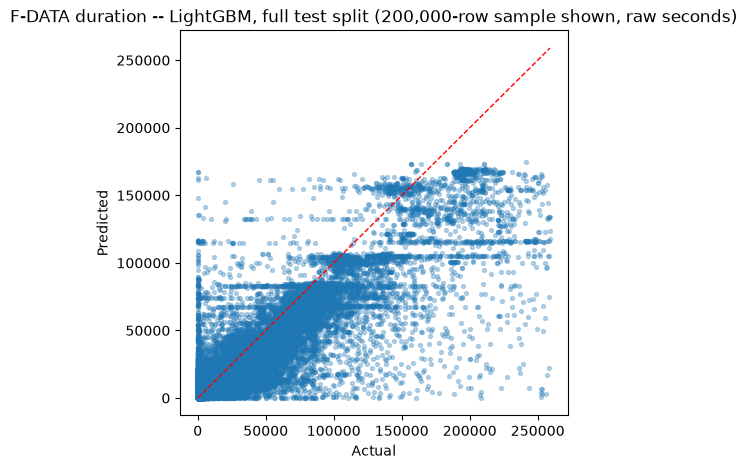

In [16]:
import pathlib

import matplotlib.pyplot as plt

FIGURES_DIR = pathlib.Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

_plot_n = min(PLOT_SAMPLE, len(X_test))
_pi = np.random.RandomState(SEED).permutation(len(X_test))[:_plot_n]
# LightGBM is the best model at full scale (R2 0.8237 vs XGBoost 0.8152).
lgbm_pred_raw_plot = features.inverse_transform_target(final_models["LightGBM"].predict(X_test.iloc[_pi]))

fig = plotting.plot_predicted_vs_actual(
    y_test_raw[_pi], lgbm_pred_raw_plot,
    f"F-DATA duration -- LightGBM, full test split ({_plot_n:,}-row sample shown, raw seconds)"
)
fig.savefig(FIGURES_DIR / "fdata_duration_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 13b-ii: LightGBM residuals

Residual (actual − predicted) against actual on a log x-axis, same 200k-row `_pi` subset as Step 13b (not resampled).

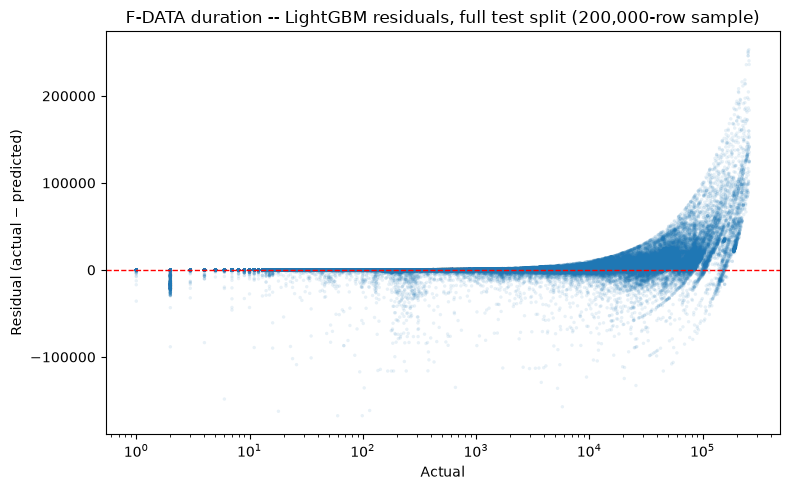

In [17]:
fig = plotting.plot_residuals(
    y_test_raw[_pi], lgbm_pred_raw_plot,
    f"F-DATA duration -- LightGBM residuals, full test split ({_plot_n:,}-row sample)"
)
fig.savefig(FIGURES_DIR / "fdata_duration_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 13b-iii: absolute error by job-size bucket

Quantile-bucketed by `cnumr` (cores requested, F-DATA's job-size proxy per `features._JOB_SIZE_COL`), absolute error per bucket on a log y-axis, same `_pi` subset.

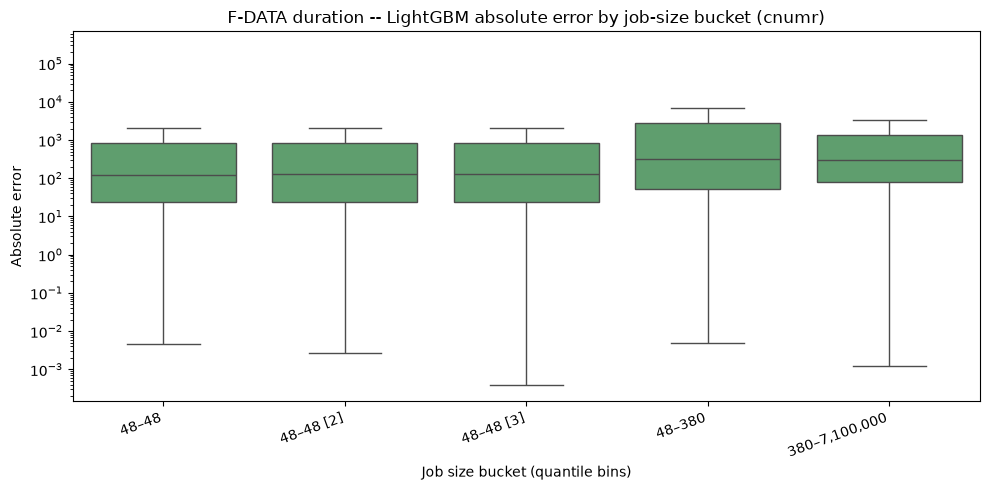

In [18]:
fig = plotting.plot_error_by_size_bucket(
    test_df["cnumr"].to_numpy()[_pi], y_test_raw[_pi], lgbm_pred_raw_plot,
    "F-DATA duration -- LightGBM absolute error by job-size bucket (cnumr)", n_buckets=5,
    model="LightGBM",
)
fig.savefig(FIGURES_DIR / "fdata_duration_error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 13c: Model comparison, R² vs. MAPE

Both metrics side by side, not just R² alone. The point is to make the disagreement visible: notebook 03's Roofline baseline beat all three of these models on MAPE while losing badly on R² (see the "Analytical Baselines" and "Classical ML Baselines" sections of `EXPERIMENT_TRACKER.md`), and that same tension shows up again within these four rows.

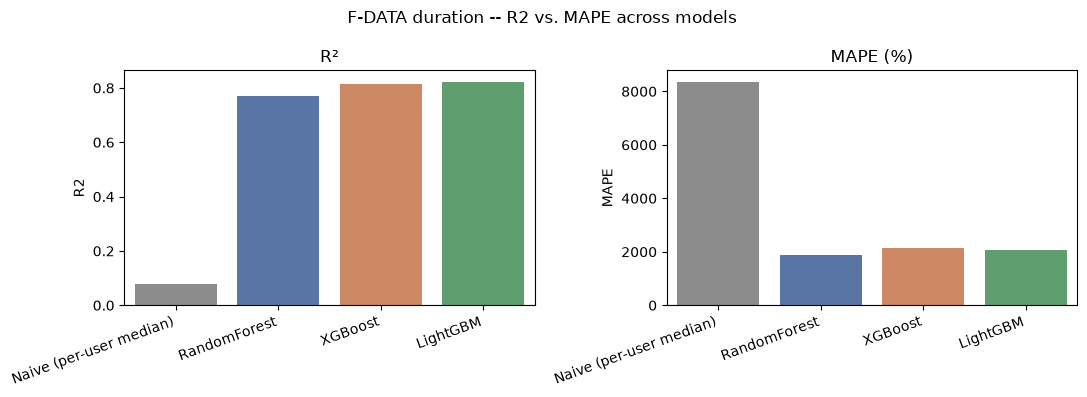

In [19]:
fig = plotting.plot_model_comparison(summary_df, "F-DATA duration -- R2 vs. MAPE across models")
fig.savefig(FIGURES_DIR / "fdata_duration_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 13d: Feature importance, LightGBM gain vs. SHAP

Gain-based importance (`Booster.feature_importance(importance_type="gain")`) and SHAP mean |value|, on the already-fitted **LightGBM** model (the full-scale best), shown side by side since the two can disagree when one feature dominates early splits. Ranked by SHAP, the more trustworthy of the two here.

SHAP computed on 200,000 of 6,992,514 test rows (LightGBM)


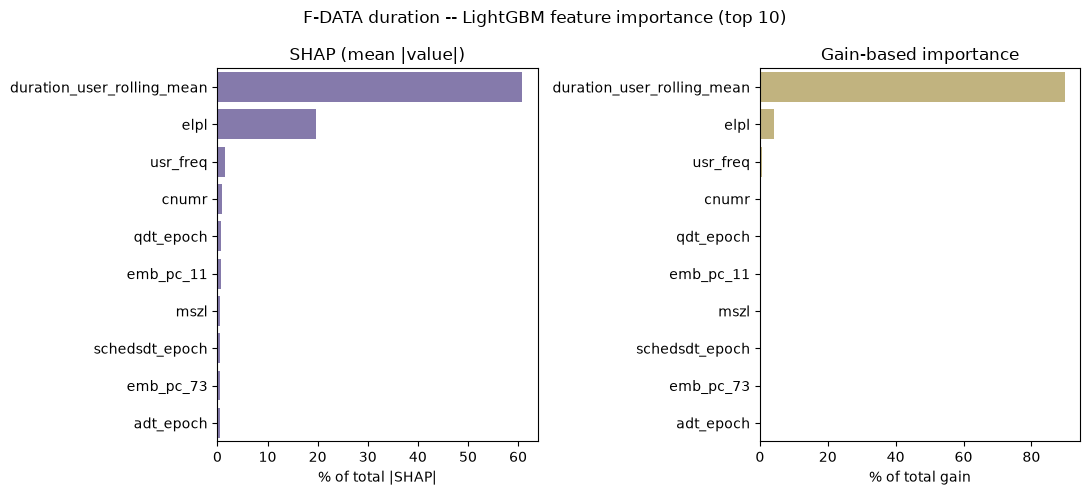

In [20]:
import shap

best_model = final_models["LightGBM"]
gain_importance = pd.Series(
    best_model.booster_.feature_importance(importance_type="gain"), index=X_train.columns
)

_shap_n = min(SHAP_SAMPLE, len(X_test))
_si = np.random.RandomState(SEED).permutation(len(X_test))[:_shap_n]
X_shap = X_test.iloc[_si]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train.columns)
print(f"SHAP computed on {_shap_n:,} of {len(X_test):,} test rows (LightGBM)")

fig = plotting.plot_feature_importance_comparison(
    gain_importance, shap_importance,
    "F-DATA duration -- LightGBM feature importance (top 10)", top_n=10,
)
fig.savefig(FIGURES_DIR / "fdata_duration_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 13e: metrics heatmap

MAE/RMSE/R²/MAPE/MedAE/Within20pct across all four models, each column min-max normalised independently (inverted for lower-is-better metrics); cells annotated with the real values, green = best-in-column.

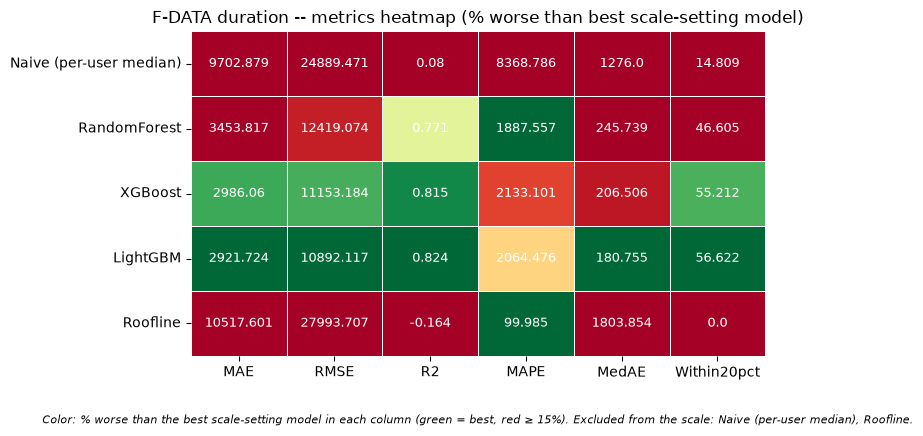

In [21]:
_roofline_row = pd.DataFrame(
    [{"MAE": 10517.6011, "RMSE": 27993.7073, "R2": -0.1644, "MAPE": 99.9848,
      "MedAE": 1803.8535, "Within20pct": 0.0}],  # notebook 03 full-scale run
    index=["Roofline"],
)
summary_df_h = pd.concat([summary_df, _roofline_row])
fig = plotting.plot_metrics_heatmap(
    summary_df_h,
    "F-DATA duration -- metrics heatmap (% worse than best scale-setting model)",
    exclude_from_scale=["Naive (per-user median)", "Roofline"],
)
fig.savefig(FIGURES_DIR / "fdata_duration_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 13f: absolute-error boxplot across models

Absolute-error distribution per model (naive + RF + XGBoost + LightGBM) on the same 200k-row `_pi` subset, log y-axis, outliers hidden.

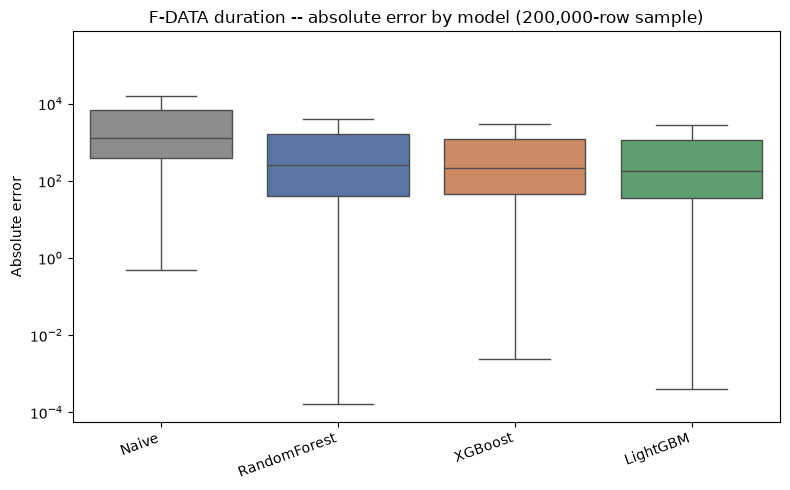

In [22]:
_box_preds = {
    "Naive": naive_pred[_pi],
    "RandomForest": features.inverse_transform_target(final_models["RandomForest"].predict(X_test.iloc[_pi])),
    "XGBoost": features.inverse_transform_target(final_models["XGBoost"].predict(X_test.iloc[_pi])),
    "LightGBM": lgbm_pred_raw_plot,
}
fig = plotting.plot_error_boxplot(
    y_test_raw[_pi], _box_preds,
    f"F-DATA duration -- absolute error by model ({_plot_n:,}-row sample)"
)
fig.savefig(FIGURES_DIR / "fdata_duration_error_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 13g: feature correlation on the final model-input matrix

Notebook 02's Step 2b ran this same pair of plots on the **raw candidate columns**, before encoding. This is the **complete** version: the actual, final columns the model was trained on (`X_train`), including engineered features like the `window=5` rolling-stat mean: everything except the `emb_pc_*` PCA components, which are near-orthogonal by construction and would only add visual noise.

The feature-feature heatmap is the direct, data-level explanation for notebook 03's physically-backwards PM100 power-model coefficients: where two columns are strongly correlated, a linear form cannot attribute the outcome to one over the other, so individual coefficients become unstable / sign-flipped even when the model's *predictions* are sound. Trees are far less sensitive to this, but it still matters for any SHAP / importance reading.

Result 1 scope only. Result 2's expanded feature set is not re-plotted here.

Only `duration` (the target modelled in this notebook) is shown here; the feature matrix was engineered for it (the rolling-stat column is `duration_user_rolling_mean`, with no memory/power equivalent). The raw-column correlation screen for the other two F-DATA targets, `mmszu` (used memory) and `avgpcon` (power), is in notebook 02's Step 2b.


In [ ]:
_xtrain_noemb = X_train[[c for c in X_train.columns if not c.startswith("emb_pc_")]]
print(f"F-DATA correlation check on {_xtrain_noemb.shape[1]} non-embedding columns: {list(_xtrain_noemb.columns)}")

fig = plotting.plot_feature_target_correlation(
    _xtrain_noemb, y_train_raw,
    "F-DATA -- final model-input features vs raw duration (Result 1, emb_pc_* excluded)")
fig.savefig(FIGURES_DIR / "fdata_duration_feature_target_corr.png", dpi=150, bbox_inches="tight"); plt.show()

fig = plotting.plot_feature_correlation_heatmap(
    _xtrain_noemb,
    "F-DATA -- final model-input: feature + target correlation (Result 1, emb_pc_* excluded)",
    target=y_train_raw, target_name="duration")
fig.savefig(FIGURES_DIR / "fdata_duration_feature_corr_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

Pipeline executed: load all 38 F-DATA months -> exclude non-completed jobs -> `mszl` sentinel fix -> rolling-stat feature on the full timeline -> chronological split -> a stratified 1M-row tuning sample within the train split (Optuna search + embedding-PCA fit only) -> Tier A matrix + leakage re-check on the full splits -> embedding PCA fit on the tuning sample, applied to the full splits -> full numeric encoding -> log1p target + round-trip check -> naive per-user-median baseline on the full test split -> chronological tune/val carve-out -> hyperparameter selection (this pass reuses the stored full-scale winners via `SKIP_TUNING`, no re-search) -> single final fit per model on the full train split (RandomForest capped at `RF_FINAL_FIT_CAP`), evaluated on the full test split.

**LightGBM is the best model at full scale** (R² 0.8237), overtaking XGBoost (0.8152). The dev-scale run had XGBoost ahead. Diagnostics from Step 13b on use LightGBM.

Figures after the results table (`notebooks/figures/`): predicted-vs-actual scatter, LightGBM residuals, absolute error by job-size bucket (cnumr), a per-column metrics heatmap over MAE/RMSE/R²/MAPE/MedAE/Within20pct, an absolute-error boxplot across all four models, an R²/MAPE comparison bar chart, and a LightGBM gain-vs-SHAP importance comparison.

**Deferred, not in scope for this pass:**
- **F-DATA's `memory` (`mmszu`) and `power` (`avgpcon`) targets.** `duration` only here.
- **Multi-seed repeats.** Single-seed fit, not mean ± std across `TuningBudget.seeds` (notebook 08).

## Part 1c: Result 2 (Extended Rolling-Stat Windows, Item 3)

This section is **additive**. Result 1 above (window=5 only) is left exactly as it is; Result 2 below adds `window=20` and `window=50` user rolling-stat columns alongside it and re-fits the same three models on the larger feature matrix.

- `features.add_user_rolling_stat` is called three times total (`window=5` already done in Step 3; `window=20` and `window=50` added here), all with `target_col="duration"`, `dataset="fdata"`.
- **Same stored `best_params` as Result 1, no re-tuning.** This isolates the effect of the feature change alone, matching the 6-month diagnostic that motivated it.
- Same full train/test split, same `RF_FINAL_FIT_CAP`, same evaluation. Result 2 gets its own results table and its own `fdata_duration_result2_*` figures; Result 1's figures are never overwritten.

### Step 1c-1: build the extended rolling-stat columns

In [23]:
# add_user_rolling_stat writes a fixed column name, so each extra call is renamed
# before merging. `rolling_col` (window=5) is already on `fdata` from Step 3.
ROLLING_COL_W20 = f"{TARGET_COL}_user_rolling_mean_w20"
ROLLING_COL_W50 = f"{TARGET_COL}_user_rolling_mean_w50"
_roll20 = features.add_user_rolling_stat(fdata, "fdata", TARGET_COL, window=20)[rolling_col].rename(ROLLING_COL_W20)
_roll50 = features.add_user_rolling_stat(fdata, "fdata", TARGET_COL, window=50)[rolling_col].rename(ROLLING_COL_W50)
fdata_r2 = fdata.join(_roll20).join(_roll50)
rolling_cols_r2 = [rolling_col, ROLLING_COL_W20, ROLLING_COL_W50]
for c in rolling_cols_r2:
    print(f"  {c}: {fdata_r2[c].notna().sum():,} / {len(fdata_r2):,} non-null")

train_df_r2 = train_df.join(fdata_r2[[ROLLING_COL_W20, ROLLING_COL_W50]])
test_df_r2 = test_df.join(fdata_r2[[ROLLING_COL_W20, ROLLING_COL_W50]])
assert len(train_df_r2) == len(train_df) and len(test_df_r2) == len(test_df)

  duration_user_rolling_mean: 23,305,072 / 23,308,381 non-null
  duration_user_rolling_mean_w20: 23,305,072 / 23,308,381 non-null
  duration_user_rolling_mean_w50: 23,305,072 / 23,308,381 non-null


### Step 1c-2: Result 2 feature matrices

Reuses Result 1's `train_tier_a` / `test_tier_a` and the same fitted embedding PCA (`embed_train_full_pca` / `embed_test_full_pca`). Only the `extra_columns` change, so Result 2's matrix is Result 1's plus the two new rolling columns.

In [24]:
X_train_r2 = features.build_fdata_numeric_matrix(
    train_tier_a, embed_train_full_pca, extra_columns=train_df_r2[rolling_cols_r2]
).fillna(0.0)
X_test_r2 = features.build_fdata_numeric_matrix(
    test_tier_a, embed_test_full_pca, extra_columns=test_df_r2[rolling_cols_r2]
).fillna(0.0)
print(f"Result 2: X_train_r2 {X_train_r2.shape}  X_test_r2 {X_test_r2.shape}  "
      f"(+{X_train_r2.shape[1] - X_train.shape[1]} cols vs Result 1)")
assert X_train_r2.shape[0] == len(y_train) and X_test_r2.shape[0] == len(y_test_raw)
assert X_train_r2.shape[1] == X_train.shape[1] + 2

Result 2: X_train_r2 (16315867, 95)  X_test_r2 (6992514, 95)  (+2 cols vs Result 1)


### Step 1c-3: re-fit RF / XGBoost / LightGBM (same `best_params`, no re-tuning)

In [25]:
final_models_r2 = {
    "RandomForest": RandomForestRegressor(**best_params["RandomForest"], n_jobs=-1, random_state=SEED),
    "XGBoost": XGBRegressor(**best_params["XGBoost"], tree_method="hist", n_jobs=-1, random_state=SEED),
    "LightGBM": LGBMRegressor(**best_params["LightGBM"], bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1),
}
rf_cap_r2 = min(RF_FINAL_FIT_CAP, len(X_train_r2))
rf_rows_r2 = np.random.RandomState(SEED).permutation(len(X_train_r2))[:rf_cap_r2]
fit_data_r2 = {
    "RandomForest": (X_train_r2.iloc[rf_rows_r2], y_train[rf_rows_r2]),
    "XGBoost": (X_train_r2, y_train),
    "LightGBM": (X_train_r2, y_train),
}

fit_seconds_r2, results_r2 = {}, {}
for name, model in final_models_r2.items():
    Xf, yf = fit_data_r2[name]
    start = time.perf_counter()
    model.fit(Xf, yf)
    fit_seconds_r2[name] = time.perf_counter() - start
    pred_log = model.predict(X_test_r2)
    pred_raw = features.inverse_transform_target(pred_log)
    results_r2[name] = {
        "log_space": metrics.regression_metrics(y_test, pred_log),
        "raw_space": metrics.regression_metrics(y_test_raw, pred_raw),
    }
    print(f"{name}: fit on {len(Xf):,} rows, time={fit_seconds_r2[name]:.1f}s")

RandomForest: fit on 5,000,000 rows, time=1266.0s


XGBoost: fit on 16,315,867 rows, time=181.5s


LightGBM: fit on 16,315,867 rows, time=244.8s


### Step 1c-4: Result 2 results table

In [26]:
print("=" * 70)
print(f"RESULT 2 -- F-DATA {TARGET_COL}, FULL test split (n={len(test_df):,})  |  rolling windows 5 + 20 + 50")
print("=" * 70)

summary_rows_r2 = [{"model": "Naive (per-user median)", **naive_metrics}]
for name in final_models_r2:
    summary_rows_r2.append({"model": name, **results_r2[name]["raw_space"]})
summary_df_r2 = pd.DataFrame(summary_rows_r2).set_index("model")
print(f"\nRaw-space (seconds) -- Result 2 (RandomForest fit on {rf_cap_r2:,} of {len(X_train_r2):,} rows):")
display(summary_df_r2.round(4))

log_df_r2 = pd.DataFrame([{"model": n, **results_r2[n]["log_space"]} for n in final_models_r2]).set_index("model")
print("\nLog-space (back-transform check):")
display(log_df_r2.round(4))

print("\nResult 2 final-fit time per model:")
for name in final_models_r2:
    print(f"  {name}: final_fit={fit_seconds_r2[name]:.1f}s")

RESULT 2 -- F-DATA duration, FULL test split (n=6,992,514)  |  rolling windows 5 + 20 + 50

Raw-space (seconds) -- Result 2 (RandomForest fit on 5,000,000 of 16,315,867 rows):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
Naive (per-user median),9702.8785,24889.4708,0.0796,8368.7861,1276.0000,14.8090
RandomForest,2748.5697,10991.5021,0.8205,1960.4995,164.1498,61.8745
XGBoost,2714.3641,10509.5175,0.8359,1923.6291,159.5601,60.3646
LightGBM,2780.6748,10676.0911,0.8306,1974.5775,195.9394,60.7888



Log-space (back-transform check):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
RandomForest,0.3607,0.8003,0.8923,9.3145,0.1373,92.9292
XGBoost,0.3653,0.8050,0.8910,9.4589,0.1428,92.9049
LightGBM,0.3645,0.7936,0.8941,9.0927,0.1510,93.0093



Result 2 final-fit time per model:
  RandomForest: final_fit=1266.0s
  XGBoost: final_fit=181.5s
  LightGBM: final_fit=244.8s


### Step 1c-5: Result 2 figures

Same six diagnostics Result 1 has (predicted-vs-actual, residuals, error-by-size, metrics heatmap, error boxplot, feature importance), generated fresh for the Result 2 feature set. **The per-model diagnostic model differs between the two results, on purpose: Result 1 uses LightGBM (its actual best, R² 0.8237), Result 2 uses XGBoost (its actual best, R² 0.8359 vs LightGBM's 0.8306).** Each result is shown with its own winning model, which is the honest comparison. This is intentional, not an inconsistency.

**The best-performing model changed between the two results: LightGBM in Result 1, XGBoost in Result 2.** The extended rolling windows lifted XGBoost past LightGBM.

Saved with the `fdata_duration_result2_` prefix so Result 1's figures are untouched. The 200k-row `_pi` and `_si` subsets from Result 1 are reused (`X_test_r2` has the same rows in the same order as `X_test`).

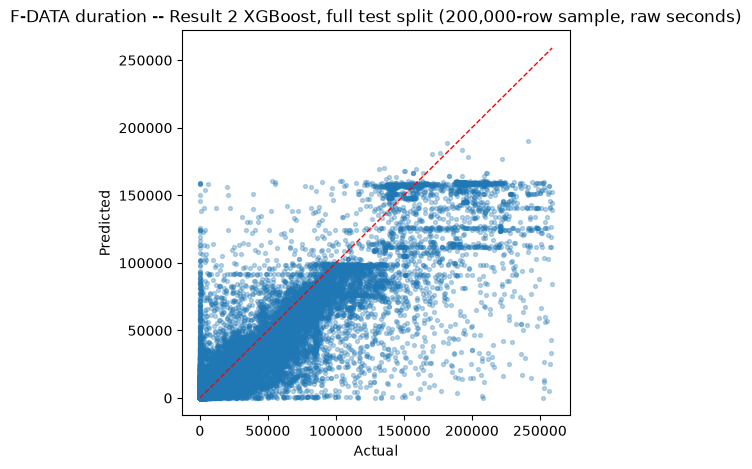

In [27]:
xgb_pred_raw_plot_r2 = features.inverse_transform_target(
    final_models_r2["XGBoost"].predict(X_test_r2.iloc[_pi])
)

fig = plotting.plot_predicted_vs_actual(
    y_test_raw[_pi], xgb_pred_raw_plot_r2,
    f"F-DATA duration -- Result 2 XGBoost, full test split ({_plot_n:,}-row sample, raw seconds)"
)
fig.savefig(FIGURES_DIR / "fdata_duration_result2_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

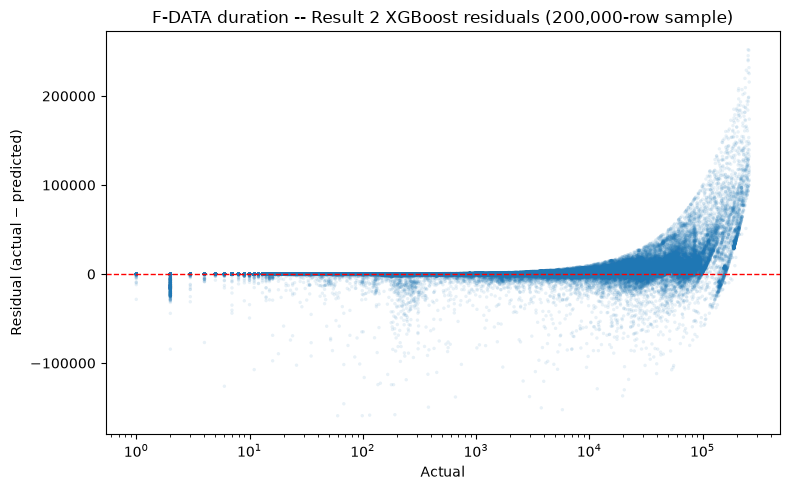

In [28]:
fig = plotting.plot_residuals(
    y_test_raw[_pi], xgb_pred_raw_plot_r2,
    f"F-DATA duration -- Result 2 XGBoost residuals ({_plot_n:,}-row sample)"
)
fig.savefig(FIGURES_DIR / "fdata_duration_result2_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

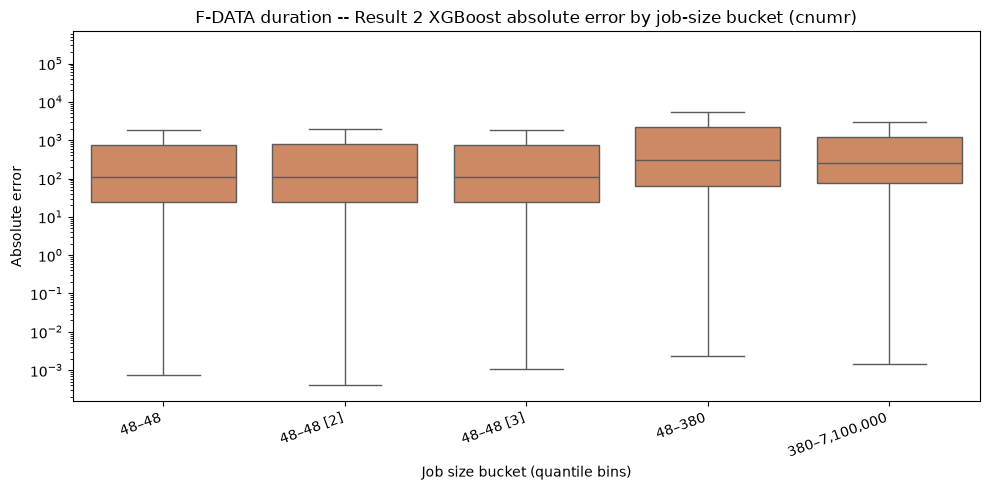

In [29]:
fig = plotting.plot_error_by_size_bucket(
    test_df_r2["cnumr"].to_numpy()[_pi], y_test_raw[_pi], xgb_pred_raw_plot_r2,
    "F-DATA duration -- Result 2 XGBoost absolute error by job-size bucket (cnumr)",
    n_buckets=5, model="XGBoost",
)
fig.savefig(FIGURES_DIR / "fdata_duration_result2_error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

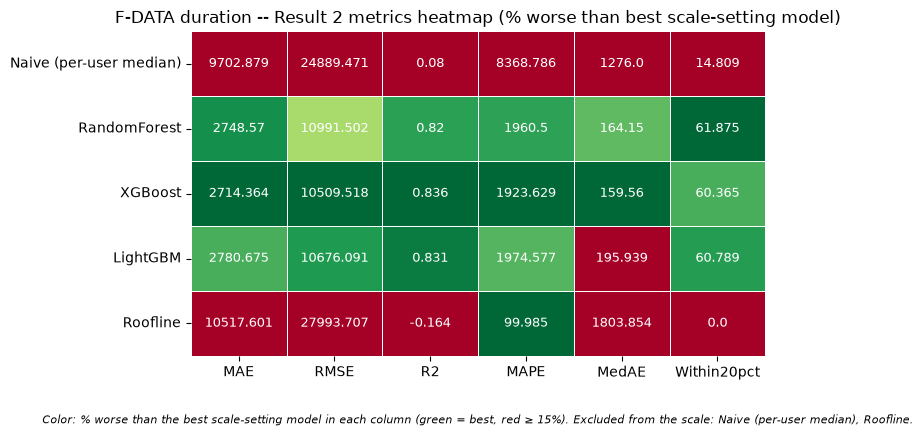

In [30]:
_roofline_row = pd.DataFrame(
    [{"MAE": 10517.6011, "RMSE": 27993.7073, "R2": -0.1644, "MAPE": 99.9848,
      "MedAE": 1803.8535, "Within20pct": 0.0}],  # notebook 03 full-scale run
    index=["Roofline"],
)
summary_df_r2_h = pd.concat([summary_df_r2, _roofline_row])
fig = plotting.plot_metrics_heatmap(
    summary_df_r2_h,
    "F-DATA duration -- Result 2 metrics heatmap (% worse than best scale-setting model)",
    exclude_from_scale=["Naive (per-user median)", "Roofline"],
)
fig.savefig(FIGURES_DIR / "fdata_duration_result2_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

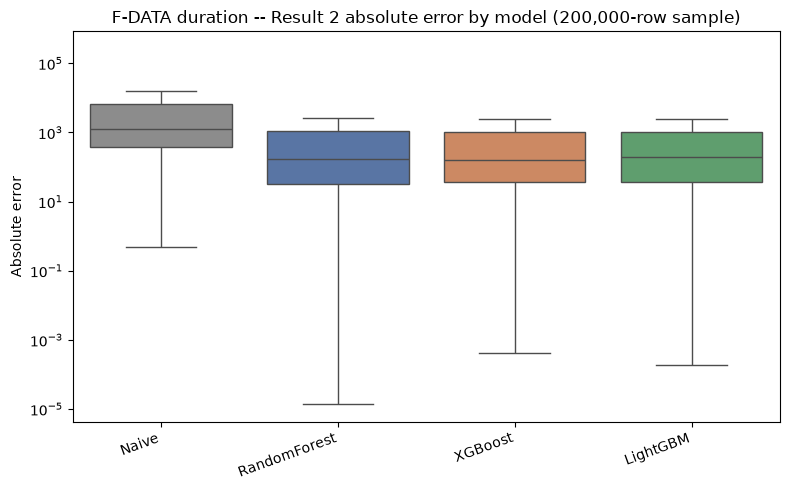

In [31]:
_box_preds_r2 = {
    "Naive": naive_pred[_pi],
    "RandomForest": features.inverse_transform_target(final_models_r2["RandomForest"].predict(X_test_r2.iloc[_pi])),
    "XGBoost": xgb_pred_raw_plot_r2,
    "LightGBM": features.inverse_transform_target(final_models_r2["LightGBM"].predict(X_test_r2.iloc[_pi])),
}
fig = plotting.plot_error_boxplot(
    y_test_raw[_pi], _box_preds_r2,
    f"F-DATA duration -- Result 2 absolute error by model ({_plot_n:,}-row sample)"
)
fig.savefig(FIGURES_DIR / "fdata_duration_result2_error_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Result 2 SHAP computed on 200,000 of 6,992,514 test rows (XGBoost)


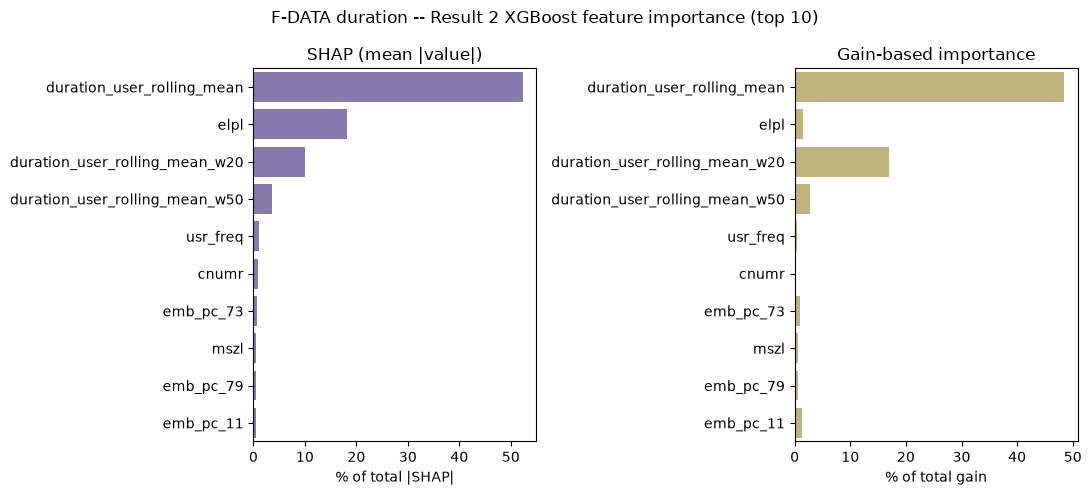

In [32]:
best_model_r2 = final_models_r2["XGBoost"]
# XGBoost gain importance: get_score omits features never used in a split, so reindex+fill.
gain_importance_r2 = (
    pd.Series(best_model_r2.get_booster().get_score(importance_type="gain"))
    .reindex(X_train_r2.columns)
    .fillna(0.0)
)
X_shap_r2 = X_test_r2.iloc[_si]
explainer_r2 = shap.TreeExplainer(best_model_r2)
shap_values_r2 = explainer_r2.shap_values(X_shap_r2)
shap_importance_r2 = pd.Series(np.abs(shap_values_r2).mean(axis=0), index=X_train_r2.columns)
print(f"Result 2 SHAP computed on {len(X_shap_r2):,} of {len(X_test_r2):,} test rows (XGBoost)")

fig = plotting.plot_feature_importance_comparison(
    gain_importance_r2, shap_importance_r2,
    "F-DATA duration -- Result 2 XGBoost feature importance (top 10)", top_n=10,
)
fig.savefig(FIGURES_DIR / "fdata_duration_result2_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 1d: Result 1 vs Result 2, the Item 3 effect

Both results side by side in one place: Result 1 = baseline (window=5 only), Result 2 = with Item 3's window=20/50 additions. Same columns (MAE/RMSE/R²/MAPE/MedAE/Within20pct). The naive row is identical in both (it is feature-independent) and is shown once.

Result 1 vs Result 2 -- stacked:


MAE        RMSE  \
result                    model                                            
Result 1 (window=5)       Naive (per-user median)  9702.8785  24889.4708   
                          RandomForest             3453.8171  12419.0736   
                          XGBoost                  2986.0604  11153.1835   
                          LightGBM                 2921.7242  10892.1171   
Result 2 (window=5/20/50) Naive (per-user median)  9702.8785  24889.4708   
                          RandomForest             2748.5697  10991.5021   
                          XGBoost                  2714.3641  10509.5175   
                          LightGBM                 2780.6748  10676.0911   

                                                       R2       MAPE  \
result                    model                                        
Result 1 (window=5)       Naive (per-user median)  0.0796  8368.7861   
                          RandomForest             0.7708  1887.5566   
                          XGBoost                  0.8152  2133.1015   
                          LightGBM                 0.8237  2064.4761   
Result 2 (window=5/20/50) Naive (per-user median)  0.0796  8368.7861   
                          RandomForest             0.8205  1960.4995   
                          XGBoost                  0.8359  1923.6291   
                          LightGBM                 0.8306  1974.5775   

                                                       MedAE  Within20pct  
result                    model                                            
Result 1 (window=5)       Naive (per-user median)  1276.0000      14.8090  
                          RandomForest              245.7386      46.6053  
                          XGBoost                   206.5059      55.2116  
                          LightGBM                  180.7551      56.6224  
Result 2 (window=5/20/50) Naive (per-user median)  1276.0000      14.8090  
                          RandomForest              164.1498      61.8745  
                          XGBoost                   159.5601      60.3646  
                          LightGBM                  195.9394      60.7888


Result 2 minus Result 1  (R2 / Within20pct: higher is better; MAE / RMSE / MAPE / MedAE: lower is better):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
RandomForest,-705.2474,-1427.5715,0.0497,72.9429,-81.5888,15.2692
XGBoost,-271.6963,-643.6660,0.0207,-209.4724,-46.9458,5.1530
LightGBM,-141.0494,-216.0260,0.0069,-89.8986,15.1843,4.1664


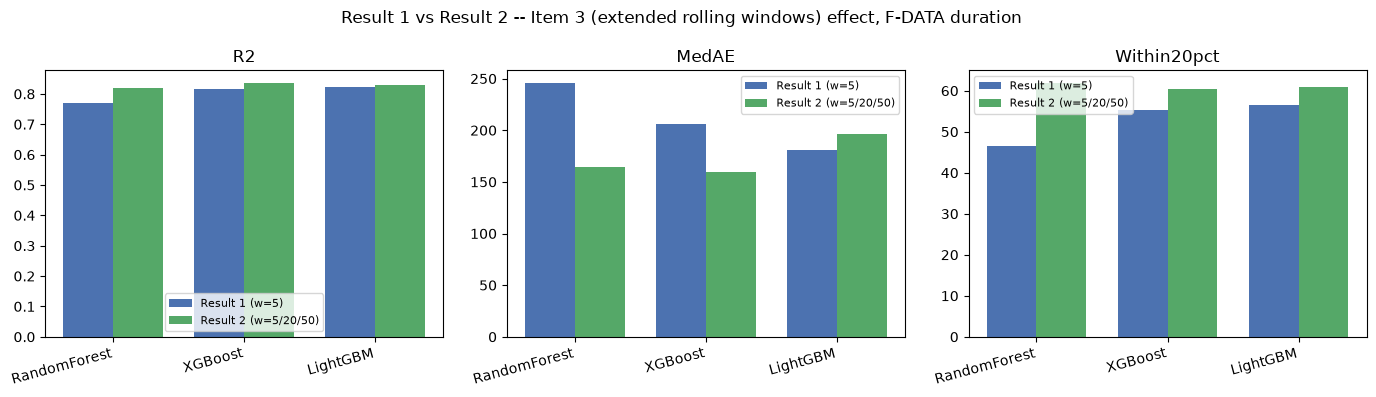

In [33]:
def _tag(sdf, label):
    d = sdf.copy()
    d.insert(0, "result", label)
    return d

comparison_df = pd.concat([
    _tag(summary_df, "Result 1 (window=5)"),
    _tag(summary_df_r2, "Result 2 (window=5/20/50)"),
]).reset_index().set_index(["result", "model"])
print("Result 1 vs Result 2 -- stacked:")
display(comparison_df.round(4))

_mods = [m for m in summary_df.index if m != "Naive (per-user median)"]
delta_df = (summary_df_r2.loc[_mods] - summary_df.loc[_mods]).round(4)
print("\nResult 2 minus Result 1  (R2 / Within20pct: higher is better; MAE / RMSE / MAPE / MedAE: lower is better):")
display(delta_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = np.arange(len(_mods)); w = 0.38
for ax, col in zip(axes, ["R2", "MedAE", "Within20pct"]):
    ax.bar(x - w/2, summary_df.loc[_mods, col], w, label="Result 1 (w=5)", color="#4C72B0")
    ax.bar(x + w/2, summary_df_r2.loc[_mods, col], w, label="Result 2 (w=5/20/50)", color="#55A868")
    ax.set_xticks(x); ax.set_xticklabels(_mods, rotation=15, ha="right")
    ax.set_title(col); ax.legend(fontsize=8)
fig.suptitle("Result 1 vs Result 2 -- Item 3 (extended rolling windows) effect, F-DATA duration")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fdata_duration_result1_vs_result2.png", dpi=150, bbox_inches="tight")
plt.show()

# Part 2: PM100 Power Target

Same three models (Random Forest, XGBoost, LightGBM) and the same fixed Optuna tuning budget as Part 1, applied to PM100's `power_mean` target instead of F-DATA's `duration`. PM100's full dataset (231,238 raw rows) is smaller than Part 1's own `SAMPLE_SIZE`, so no sampling step is used here; the full chronological train/test split is used directly, matching how notebook 03 already treats PM100 throughout.

In [34]:
PM100_PATH = "../data/raw/pm100/pm100_job_table.parquet"
PM100_TARGET_COL = "power_mean"   # derived scalar -- see Step 14, not a raw column
PM100_TUNE_TRAIN_FRAC = 0.8       # same chronological tune/val carve-out pattern as Part 1

print(f"PM100_TARGET_COL={PM100_TARGET_COL}  N_TRIALS={N_TRIALS}")

PM100_TARGET_COL=power_mean  N_TRIALS=50


## Step 14: Load PM100 in full, exclude non-completed jobs, reduce power to a scalar

No sampling here: PM100's full dataset is already smaller than Part 1's `SAMPLE_SIZE`. `node_power_consumption` is a raw per-job time series (20-second-interval samples), not a scalar, so it is reduced to its per-job mean immediately after filtering, before anything else touches the power column, the same order notebook 03 uses.

In [35]:
pm100 = pd.read_parquet(PM100_PATH)
print(f"PM100 raw rows: {len(pm100):,}")

pm100 = features.filter_completed_jobs(pm100, "pm100")
pm100["power_mean"] = pm100["node_power_consumption"].apply(np.mean)
print(f"rows after filtering: {len(pm100):,}")

PM100 raw rows: 231,238
[pm100] excluded 22.0% of jobs as non-completed (50928 / 231238)


rows after filtering: 180,310


## Step 15: Feature Vetting derived indicators

`num_tasks_missing` (the one Feature Vetting flag promoted to active Tier A, per notebook 02's Check 1-3) isn't a raw parquet column; it's derived by `add_pm100_derived_indicators`, which must run before `build_tier_a_features` or that call fails with a `KeyError`. `assert_reserved_columns_preserved` re-checks that the excluded flags (`node_pinned`, `threads_per_core_set`, `req_switch_set`) stay preserved in the dataframe but out of the active Tier A list.

In [36]:
pm100 = features.add_pm100_derived_indicators(pm100)
features.assert_reserved_columns_preserved(pm100)
print("reserved columns preserved:", [c for c in features.PM100_RESERVED_COLUMNS if c in pm100.columns])
print("num_tasks_missing present:", "num_tasks_missing" in pm100.columns)

reserved columns preserved: ['req_nodes', 'threads_per_core', 'req_switch', 'node_pinned', 'threads_per_core_set', 'req_switch_set']
num_tasks_missing present: True


## Step 16: Historical rolling-stat feature (Tier A)

Same reasoning as Part 1's Step 3: computed on the full chronologically-ordered dataset, before the split below, so a job on the test side of the later split still gets credit for that user's real training-period history rather than an artificially truncated one.

In [37]:
pm100 = features.add_user_rolling_stat(pm100, "pm100", PM100_TARGET_COL, window=5)
pm100_rolling_col = f"{PM100_TARGET_COL}_user_rolling_mean"
print(f"rolling stat available for {pm100[pm100_rolling_col].notna().sum():,} / {len(pm100):,} jobs")

rolling stat available for 179,883 / 180,310 jobs


## Step 17: Chronological split

Same `src/splits.py` utility Part 1 uses, with `dataset="pm100"`. No stratified sampling follows this split; PM100 is used in full on both sides.

In [38]:
pm100_train_df, pm100_test_df = splits.chronological_split(pm100, "pm100")
print(f"train={len(pm100_train_df):,} test={len(pm100_test_df):,} "
      f"(test/train ratio={len(pm100_test_df) / len(pm100_train_df):.4f})")

train=126,217 test=54,093 (test/train ratio=0.4286)


## Step 18: Tier A feature matrix + leakage re-check

Re-running the same leakage sanity check Part 1 uses, on PM100's own Tier A/B column lists.

In [39]:
pm100_train_tier_a = features.build_tier_a_features(pm100_train_df, "pm100")
pm100_test_tier_a = features.build_tier_a_features(pm100_test_df, "pm100")

features.assert_no_tier_leakage(list(pm100_train_tier_a.columns), "A", "pm100")
features.assert_no_tier_leakage(list(pm100_test_tier_a.columns), "A", "pm100")
print(f"PM100 Tier A: {len(pm100_train_tier_a.columns)} columns, OK")

PM100 Tier A: 16 columns, OK


## Step 19: Final numeric feature matrix + target transform

`build_pm100_numeric_matrix` (new in `src/features.py`) mirrors `build_fdata_numeric_matrix`'s pattern but is structurally simpler: PM100 has no job-name/embedding field, so there's no PCA step. `user_id` is frequency-encoded like F-DATA's `usr`; `group_id`/`partition`/`qos`/`shared` are all factorized as low-cardinality categorical IDs; the rest are plain numeric passthrough. `.fillna(0.0)` is chained at each call site (not inside the function itself); `num_tasks` has real missing values (`num_tasks_missing` already carries that signal as its own feature) and RF has no native NaN handling, so all three model families need a finite matrix. The target gets the same log1p transform as every other heavy-tailed target in this project.

In [40]:
pm100_X_train = features.build_pm100_numeric_matrix(
    pm100_train_tier_a, extra_columns=pm100_train_df[[pm100_rolling_col]]
).fillna(0.0)
pm100_X_test = features.build_pm100_numeric_matrix(
    pm100_test_tier_a, extra_columns=pm100_test_df[[pm100_rolling_col]]
).fillna(0.0)

pm100_y_train_raw = pm100_train_df[PM100_TARGET_COL].to_numpy(dtype=float)
pm100_y_test_raw = pm100_test_df[PM100_TARGET_COL].to_numpy(dtype=float)
pm100_y_train = features.transform_target(pm100_y_train_raw)
pm100_y_test = features.transform_target(pm100_y_test_raw)

metrics.expm1_round_trip_check(pm100_y_train_raw)
metrics.expm1_round_trip_check(pm100_y_test_raw)

print(f"X_train shape: {pm100_X_train.shape}  X_test shape: {pm100_X_test.shape}")
print(f"feature columns: {list(pm100_X_train.columns)}")

X_train shape: (126217, 17)  X_test shape: (54093, 17)
feature columns: ['priority', 'time_limit', 'num_cores_req', 'num_nodes_req', 'num_gpus_req', 'mem_req', 'cores_per_task', 'num_tasks', 'num_tasks_missing', 'submit_time_epoch', 'eligible_time_epoch', 'partition_code', 'qos_code', 'shared_code', 'group_id_code', 'user_id_freq', 'power_mean_user_rolling_mean']


## Step 20: Naive per-user-median baseline

In [41]:
pm100_user_medians, pm100_global_median = baselines.fit_naive_baseline(pm100_train_df, "pm100", PM100_TARGET_COL)
pm100_naive_pred = baselines.predict_naive_baseline(pm100_test_df, "pm100", pm100_user_medians, pm100_global_median)
pm100_naive_metrics = metrics.regression_metrics(pm100_y_test_raw, pm100_naive_pred)

print("Naive per-user-median baseline (PM100 power_mean, test split):")
for k, v in pm100_naive_metrics.items():
    print(f"  {k}: {v:,.4f}")

Naive per-user-median baseline (PM100 power_mean, test split):
  MAE: 1,794.8398
  RMSE: 7,625.5207
  R2: 0.0963
  MAPE: 49.7496
  MedAE: 298.7500
  Within20pct: 28.6100


## Step 21: Chronological tuning/validation carve-out within train

Same rationale as Part 1's Step 10 (chronological tune/val carve-out): Optuna needs a validation objective distinct from the final test evaluation, so `test_df` stays untouched until the final fit.

In [42]:
pm100_tune_train_raw, pm100_tune_val_raw = splits.chronological_split(
    pm100_train_df, "pm100", train_frac=PM100_TUNE_TRAIN_FRAC
)
print(f"tune_train={len(pm100_tune_train_raw):,} tune_val={len(pm100_tune_val_raw):,}")

pm100_tune_train_tier_a = features.build_tier_a_features(pm100_tune_train_raw, "pm100")
pm100_tune_val_tier_a = features.build_tier_a_features(pm100_tune_val_raw, "pm100")

pm100_X_tune_train = features.build_pm100_numeric_matrix(
    pm100_tune_train_tier_a, extra_columns=pm100_tune_train_raw[[pm100_rolling_col]]
).fillna(0.0)
pm100_X_tune_val = features.build_pm100_numeric_matrix(
    pm100_tune_val_tier_a, extra_columns=pm100_tune_val_raw[[pm100_rolling_col]]
).fillna(0.0)

pm100_y_tune_train = features.transform_target(pm100_tune_train_raw[PM100_TARGET_COL].to_numpy(dtype=float))
pm100_y_tune_val = features.transform_target(pm100_tune_val_raw[PM100_TARGET_COL].to_numpy(dtype=float))

print(f"X_tune_train shape: {pm100_X_tune_train.shape}  X_tune_val shape: {pm100_X_tune_val.shape}")

tune_train=100,973 tune_val=25,244


X_tune_train shape: (100973, 17)  X_tune_val shape: (25244, 17)


## Step 22: Optuna hyperparameter search (RF / XGBoost / LightGBM)

Same fixed budget (`N_TRIALS` trials per model family) and the same per-family search-space ranges as Part 1: the ranges are a property of the model family, not the dataset, so keeping them identical here is the more defensible choice rather than a fresh judgment call.

In [43]:
def pm100_rf_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 250),
        max_depth=trial.suggest_int("max_depth", 4, 18),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
    )
    model = RandomForestRegressor(**params, n_jobs=-1, random_state=SEED)
    model.fit(pm100_X_tune_train, pm100_y_tune_train)
    pred = model.predict(pm100_X_tune_val)
    return float(np.sqrt(np.mean((pm100_y_tune_val - pred) ** 2)))


def pm100_xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
    )
    model = XGBRegressor(**params, tree_method="hist", n_jobs=-1, random_state=SEED)
    model.fit(pm100_X_tune_train, pm100_y_tune_train)
    pred = model.predict(pm100_X_tune_val)
    return float(np.sqrt(np.mean((pm100_y_tune_val - pred) ** 2)))


def pm100_lgbm_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 500),
        num_leaves=trial.suggest_int("num_leaves", 15, 255),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
    )
    # bagging_freq must be >0 for `subsample` to have any effect in LightGBM
    # (it silently no-ops otherwise) -- fixed, not tuned, same as Part 1.
    model = LGBMRegressor(**params, bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1)
    model.fit(pm100_X_tune_train, pm100_y_tune_train)
    pred = model.predict(pm100_X_tune_val)
    return float(np.sqrt(np.mean((pm100_y_tune_val - pred) ** 2)))


pm100_objectives = {
    "RandomForest": pm100_rf_objective, "XGBoost": pm100_xgb_objective, "LightGBM": pm100_lgbm_objective,
}
SKIP_TUNING_PM100 = True  # same as Part 1: reuse the stored full-scale winners (d48ac0c),
                          # do NOT re-run the search. Set False to re-tune.
_STORED_PM100_BEST_PARAMS = {
    "RandomForest": {"n_estimators": 229, "max_depth": 9, "min_samples_leaf": 8, "max_features": 0.48374603344981765},
    "XGBoost": {"n_estimators": 128, "max_depth": 4, "learning_rate": 0.05882341368895798, "subsample": 0.9337098444135781, "colsample_bytree": 0.9294864662794635},
    "LightGBM": {"n_estimators": 89, "num_leaves": 19, "learning_rate": 0.16977763163336626, "subsample": 0.8890783754749252, "colsample_bytree": 0.9350060741234096},
}

pm100_best_params = {}
pm100_tuning_seconds = {}

for name, objective in pm100_objectives.items():
    if SKIP_TUNING_PM100:
        pm100_best_params[name] = dict(_STORED_PM100_BEST_PARAMS[name])
        pm100_tuning_seconds[name] = 0.0
        print(f"{name}: SKIP_TUNING_PM100 -- reusing stored best_params={pm100_best_params[name]}")
        continue
    start = time.perf_counter()
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    pm100_tuning_seconds[name] = time.perf_counter() - start
    pm100_best_params[name] = study.best_params
    print(f"{name}: best RMSE(log-space)={study.best_value:.4f}  "
          f"tuning time={pm100_tuning_seconds[name]:.1f}s  n_trials={N_TRIALS}")
    print(f"    best_params={study.best_params}")

RandomForest: SKIP_TUNING_PM100 -- reusing stored best_params={'n_estimators': 229, 'max_depth': 9, 'min_samples_leaf': 8, 'max_features': 0.48374603344981765}
XGBoost: SKIP_TUNING_PM100 -- reusing stored best_params={'n_estimators': 128, 'max_depth': 4, 'learning_rate': 0.05882341368895798, 'subsample': 0.9337098444135781, 'colsample_bytree': 0.9294864662794635}
LightGBM: SKIP_TUNING_PM100 -- reusing stored best_params={'n_estimators': 89, 'num_leaves': 19, 'learning_rate': 0.16977763163336626, 'subsample': 0.8890783754749252, 'colsample_bytree': 0.9350060741234096}


## Step 23: Final fit on the full PM100 train split with the best hyperparameters, evaluate on test

One fit per model at the winning configuration, same single-seed-headline-result scope as Part 1.

In [44]:
pm100_final_models = {
    "RandomForest": RandomForestRegressor(**pm100_best_params["RandomForest"], n_jobs=-1, random_state=SEED),
    "XGBoost": XGBRegressor(**pm100_best_params["XGBoost"], tree_method="hist", n_jobs=-1, random_state=SEED),
    "LightGBM": LGBMRegressor(**pm100_best_params["LightGBM"], bagging_freq=1, n_jobs=-1, random_state=SEED, verbose=-1),
}

pm100_fit_seconds = {}
pm100_results = {}
for name, model in pm100_final_models.items():
    start = time.perf_counter()
    model.fit(pm100_X_train, pm100_y_train)
    pm100_fit_seconds[name] = time.perf_counter() - start
    pred_log = model.predict(pm100_X_test)
    pred_raw = features.inverse_transform_target(pred_log)
    pm100_results[name] = {
        "log_space": metrics.regression_metrics(pm100_y_test, pred_log),
        "raw_space": metrics.regression_metrics(pm100_y_test_raw, pred_raw),
    }
    print(f"{name}: final fit time={pm100_fit_seconds[name]:.1f}s")

RandomForest: final fit time=2.0s


XGBoost: final fit time=0.2s


LightGBM: final fit time=0.3s


## Step 24: Results for the PM100 `power_mean` target

In [45]:
print("=" * 70)
print(f"RESULTS -- PM100 {PM100_TARGET_COL} target, test split (n={len(pm100_test_df):,})")
print("=" * 70)

pm100_summary_rows = [{"model": "Naive (per-user median)", **pm100_naive_metrics}]
for name in pm100_final_models:
    pm100_summary_rows.append({"model": name, **pm100_results[name]["raw_space"]})
pm100_summary_df = pd.DataFrame(pm100_summary_rows).set_index("model")

print("\nRaw-space (Watts) metrics, full PM100 dataset (no sampling):")
display(pm100_summary_df.round(4))

pm100_log_rows = [{"model": name, **pm100_results[name]["log_space"]} for name in pm100_final_models]
pm100_log_df = pd.DataFrame(pm100_log_rows).set_index("model")
print("\nLog-space metrics (back-transform check):")
display(pm100_log_df.round(4))

print("\n" + "-" * 70)
print("Reference only -- notebook 03's calibrated power model and naive "
      "baseline, same PM100 test split (a different kind of model -- "
      "physics-form calibrated vs. tree ensemble -- not directly "
      "comparable without care, shown for context):")
print("-" * 70)
pm100_reference_df = pd.DataFrame([
    {"model": "Calibrated power model (notebook 03)", "MAE": 493.4335, "RMSE": 2408.5334, "R2": 0.9098, "MAPE": 21.8178},
    {"model": "Naive (notebook 03)", "MAE": 1794.8398, "RMSE": 7625.5207, "R2": 0.0963, "MAPE": 49.7496},
]).set_index("model")
display(pm100_reference_df)

print("\nOptuna tuning time per model family (N_TRIALS={} each):".format(N_TRIALS))
for name in pm100_final_models:
    print(f"  {name}: tuning={pm100_tuning_seconds[name]:.1f}s  final_fit={pm100_fit_seconds[name]:.1f}s")

RESULTS -- PM100 power_mean target, test split (n=54,093)

Raw-space (Watts) metrics, full PM100 dataset (no sampling):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
Naive (per-user median),1794.8398,7625.5207,0.0963,49.7496,298.7500,28.6100
RandomForest,398.3066,2513.4725,0.9018,17.0614,130.1689,66.6611
XGBoost,360.3284,2206.6780,0.9243,16.6291,123.9113,68.1696
LightGBM,372.1584,2215.1090,0.9237,17.2101,129.6627,65.3356



Log-space metrics (back-transform check):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
RandomForest,0.1750,0.2231,0.9399,2.5454,0.1471,99.9852
XGBoost,0.1656,0.2126,0.9455,2.4236,0.1371,99.9852
LightGBM,0.1748,0.2230,0.9400,2.5514,0.1494,99.9852



----------------------------------------------------------------------
Reference only -- notebook 03's calibrated power model and naive baseline, same PM100 test split (a different kind of model -- physics-form calibrated vs. tree ensemble -- not directly comparable without care, shown for context):
----------------------------------------------------------------------


,MAE,RMSE,R2,MAPE
model,,,,
Calibrated power model (notebook 03),493.4335,2408.5334,0.9098,21.8178
Naive (notebook 03),1794.8398,7625.5207,0.0963,49.7496



Optuna tuning time per model family (N_TRIALS=50 each):
  RandomForest: tuning=0.0s  final_fit=2.0s
  XGBoost: tuning=0.0s  final_fit=0.2s
  LightGBM: tuning=0.0s  final_fit=0.3s


### Step 24b: Predicted vs. actual, XGBoost (best-performing model)

Unlike Part 1, **XGBoost is still PM100's best model at full scale** (R² 0.9243 vs LightGBM's 0.9237, RandomForest's 0.9018), so no correction needed here. Same `plotting.plot_predicted_vs_actual` helper as Part 1's Step 13b; the model was already fitted in Step 23, this only calls `.predict()`.

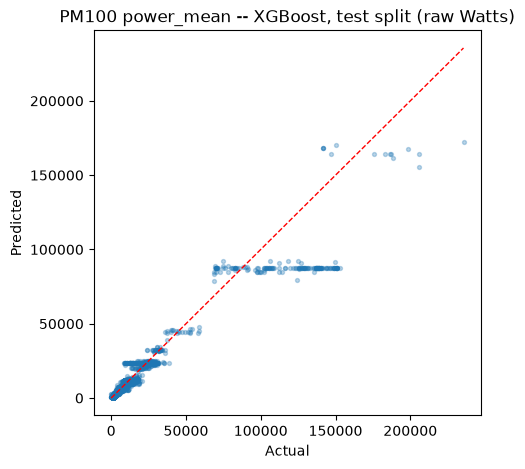

In [46]:
pm100_xgb_pred_raw = features.inverse_transform_target(pm100_final_models["XGBoost"].predict(pm100_X_test))

fig = plotting.plot_predicted_vs_actual(
    pm100_y_test_raw, pm100_xgb_pred_raw, "PM100 power_mean -- XGBoost, test split (raw Watts)"
)
fig.savefig(FIGURES_DIR / "pm100_power_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 24b-ii: XGBoost residuals

Residual (actual − predicted) against actual on a log x-axis. The whole PM100 test split (54k rows) is small enough to plot without sampling.

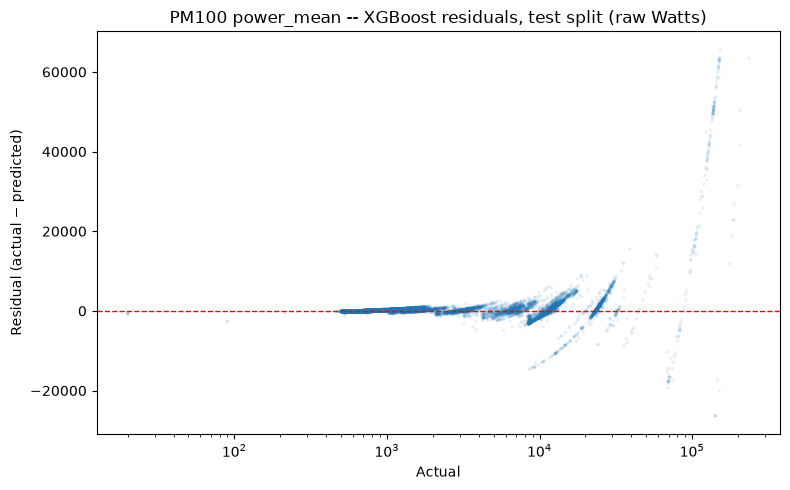

In [47]:
fig = plotting.plot_residuals(
    pm100_y_test_raw, pm100_xgb_pred_raw,
    "PM100 power_mean -- XGBoost residuals, test split (raw Watts)"
)
fig.savefig(FIGURES_DIR / "pm100_power_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 24b-iii: absolute error by job-size bucket

Quantile-bucketed by `num_cores_req` (PM100's job-size proxy, per `features._JOB_SIZE_COL`), absolute error per bucket on a log y-axis.

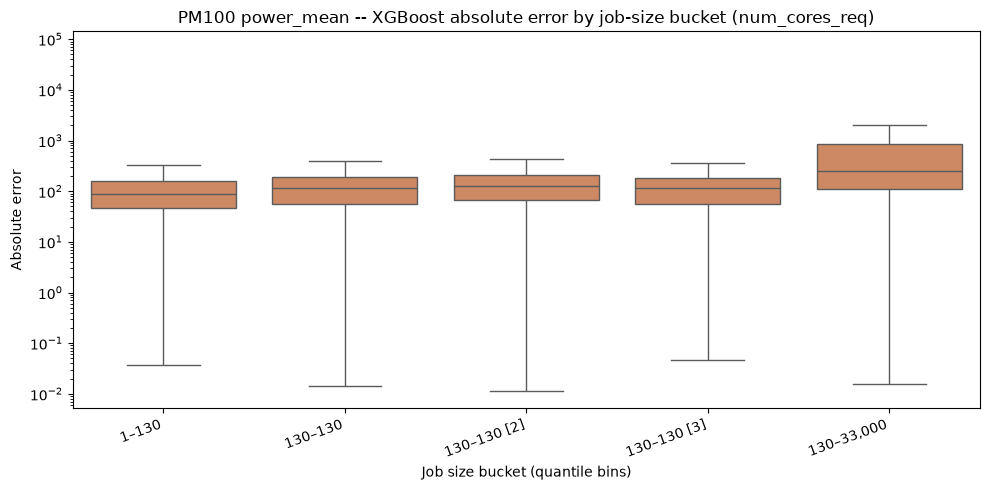

In [48]:
fig = plotting.plot_error_by_size_bucket(
    pm100_test_df["num_cores_req"].to_numpy(), pm100_y_test_raw, pm100_xgb_pred_raw,
    "PM100 power_mean -- XGBoost absolute error by job-size bucket (num_cores_req)", n_buckets=5,
    model="XGBoost",
)
fig.savefig(FIGURES_DIR / "pm100_power_error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 24e: metrics heatmap

MAE/RMSE/R²/MAPE/MedAE/Within20pct across all four models, each column min-max normalised independently (inverted for lower-is-better metrics); cells annotated with the real values, green = best-in-column.

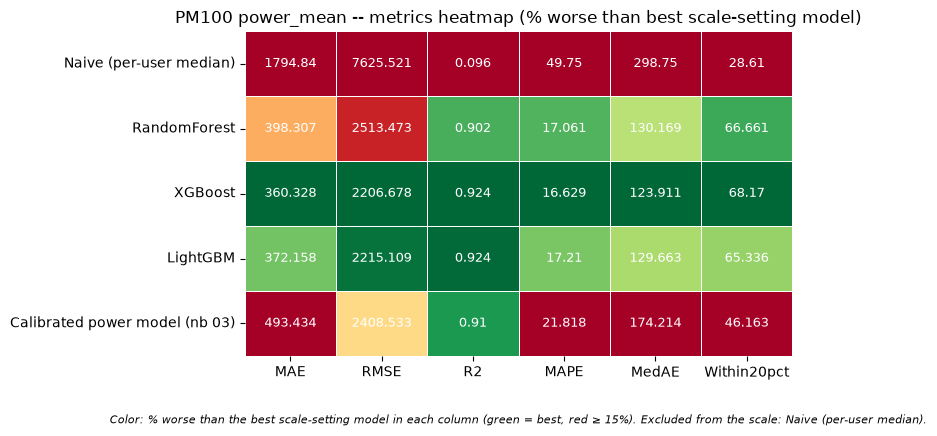

In [49]:
_calib_row = pd.DataFrame(
    [{"MAE": 493.4335, "RMSE": 2408.5334, "R2": 0.9098, "MAPE": 21.8178,
      "MedAE": 174.2141, "Within20pct": 46.1631}],  # notebook 03 calibrated power model
    index=["Calibrated power model (nb 03)"],
)
pm100_summary_df_h = pd.concat([pm100_summary_df, _calib_row])
fig = plotting.plot_metrics_heatmap(
    pm100_summary_df_h,
    "PM100 power_mean -- metrics heatmap (% worse than best scale-setting model)",
    exclude_from_scale=["Naive (per-user median)"],
)
fig.savefig(FIGURES_DIR / "pm100_power_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 24f: absolute-error boxplot across models

Absolute-error distribution per model (naive + RF + XGBoost + LightGBM), log y-axis, outliers hidden, since `plot_residuals` already shows the tail.

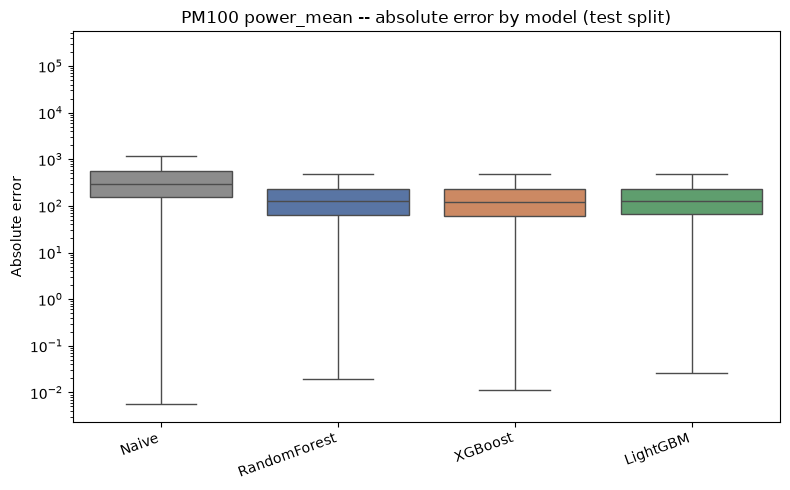

In [50]:
_pm100_box_preds = {
    "Naive": pm100_naive_pred,
    "RandomForest": features.inverse_transform_target(pm100_final_models["RandomForest"].predict(pm100_X_test)),
    "XGBoost": pm100_xgb_pred_raw,
    "LightGBM": features.inverse_transform_target(pm100_final_models["LightGBM"].predict(pm100_X_test)),
}
fig = plotting.plot_error_boxplot(
    pm100_y_test_raw, _pm100_box_preds, "PM100 power_mean -- absolute error by model (test split)"
)
fig.savefig(FIGURES_DIR / "pm100_power_error_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 24c: Model comparison, R² vs. MAPE

Same R²-vs-MAPE tension as Part 1's Step 13c, this time between notebook 03's calibrated power model and the stripped-feature XGBoost investigation (not re-plotted here; see `EXPERIMENT_TRACKER.md`'s PM100 Classical ML Baselines section), and visible again within these four rows on their own.

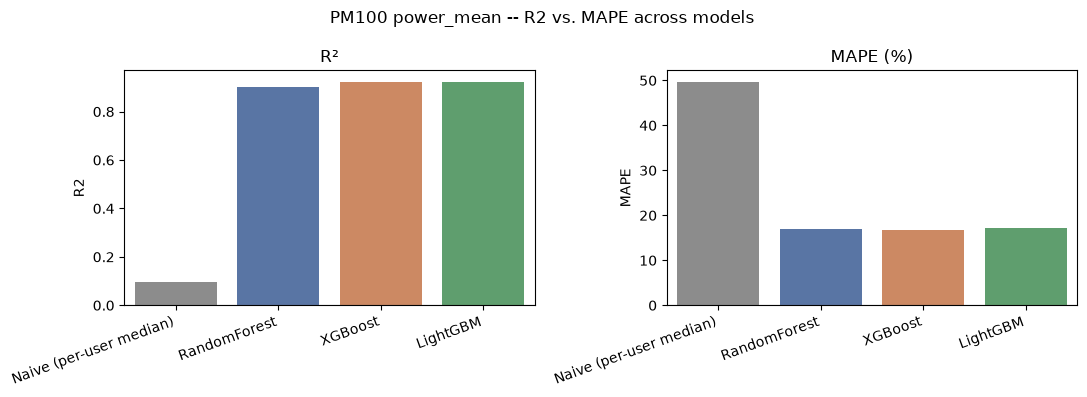

In [51]:
fig = plotting.plot_model_comparison(pm100_summary_df, "PM100 power_mean -- R2 vs. MAPE across models")
fig.savefig(FIGURES_DIR / "pm100_power_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 24d: Feature importance, XGBoost gain vs. SHAP

Same method as Part 1's Step 13d. This is the computation the "headline finding" (node count as the dominant driver, matching notebook 03's calibrated model by construction) and the SHAP-vs-gain disagreement paragraphs in `EXPERIMENT_TRACKER.md` are based on. Shown here for real, not just described.

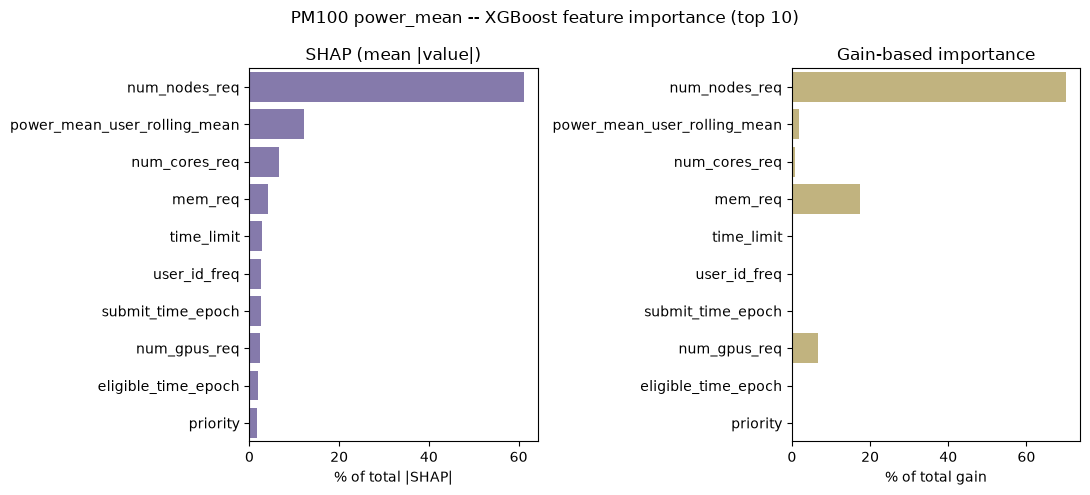

In [52]:
import shap

pm100_xgb_model = pm100_final_models["XGBoost"]
pm100_gain_importance = pd.Series(pm100_xgb_model.feature_importances_, index=pm100_X_train.columns)

pm100_explainer = shap.TreeExplainer(pm100_xgb_model)
pm100_shap_values = pm100_explainer.shap_values(pm100_X_test)
pm100_shap_importance = pd.Series(np.abs(pm100_shap_values).mean(axis=0), index=pm100_X_train.columns)

fig = plotting.plot_feature_importance_comparison(
    pm100_gain_importance, pm100_shap_importance,
    "PM100 power_mean -- XGBoost feature importance (top 10)", top_n=10,
)
fig.savefig(FIGURES_DIR / "pm100_power_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 24g: feature correlation on the final model-input matrix

Same pair as Step 13g, on PM100's final `pm100_X_train` (no `emb_pc_*` here, since PM100 has no embedding). Includes the `power_mean` rolling-stat feature.

PM100 is the case notebook 03 flagged directly: `num_nodes_alloc` / `num_cores_alloc` / `num_gpus_alloc` / `mem_alloc` are 0.85–0.97 correlated on Marconi100's fixed-ratio nodes, which is why the calibrated power model's per-GPU / per-MB coefficients came out negative. The requested-side columns used here (`num_nodes_req` etc.) carry the same collinearity, visible directly in the heatmap below.

As in Step 13g, only `power_mean` (this notebook's PM100 target) is shown. Notebook 02's Step 2b carries the raw-column screen for PM100's other targets, `run_time` and `mem_alloc`.


In [ ]:
print(f"PM100 correlation check on {pm100_X_train.shape[1]} columns: {list(pm100_X_train.columns)}")

fig = plotting.plot_feature_target_correlation(
    pm100_X_train, pm100_y_train_raw,
    "PM100 -- final model-input features vs raw power_mean (Result 1)")
fig.savefig(FIGURES_DIR / "pm100_power_feature_target_corr.png", dpi=150, bbox_inches="tight"); plt.show()

fig = plotting.plot_feature_correlation_heatmap(
    pm100_X_train,
    "PM100 -- final model-input: feature + target correlation (Result 1)",
    target=pm100_y_train_raw, target_name="power_mean")
fig.savefig(FIGURES_DIR / "pm100_power_feature_corr_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

## Part 2 Summary

Pipeline executed: load PM100 in full -> exclude non-completed jobs -> reduce `node_power_consumption` to `power_mean` -> Feature Vetting derived indicators -> rolling-stat feature -> chronological split (no sampling) -> Tier A matrix + leakage re-check -> full numeric encoding -> log1p target + round-trip check -> naive per-user-median baseline -> chronological tune/val carve-out -> hyperparameter selection (this pass reuses the stored full-scale winners via `SKIP_TUNING_PM100`) -> single final fit per model, evaluated on the held-out test split.

**XGBoost remains PM100's best model** (R² 0.9243), unlike Part 1 where LightGBM overtook it. Diagnostics use XGBoost.

Figures (`notebooks/figures/`, `pm100_power_` prefix): predicted-vs-actual scatter, XGBoost residuals, absolute error by job-size bucket (num_cores_req), a per-column metrics heatmap, an absolute-error boxplot across all four models, an R²/MAPE comparison bar chart, and an XGBoost gain-vs-SHAP importance comparison.

**Still deferred:**
- **PM100's `execution_time` (`run_time`) and `memory` (`mem_alloc`) targets.** `power_mean` only.
- **Multi-seed repeats.** Single-seed fit (notebook 08's job).